# Atividade Geral — Data Science
## People Analytics: Análise e Previsão de Desligamento de Colaboradores

---
### Informações do Squad:
* **Integrantes**: Gabriel Maia, João Lucca, Kevin Mascarenhas, Marina Gonçalves e Samuel Paulo
* **Disciplina**: Data Science
* **Tema do Projeto**: People Analytics (Recursos Humanos)
* **Base de Dados**: `MFG10YearTerminationData.csv` (Histórico de 10 anos de colaboradores)

---
## 1. Definição do Problema e Objetivo da Atividade

### Problema de Negócio
A base reúne o histórico de 2006 a 2015 dos colaboradores de uma rede varejista, com um escritório central (`HEADOFFICE`) e lojas físicas (`STORES`). Cada linha é o registro anual de um colaborador, com idade, tempo de empresa, cargo, departamento, loja e situação no ano (ativo ou desligado).

O desligamento de colaboradores gera custos de rescisão, recrutamento e treinamento, além da perda de experiência. O objetivo do negócio é identificar os fatores associados ao desligamento para permitir que o time de Gente & Gestão atue preventivamente na retenção de talentos e no planejamento sucessório.

**Pergunta do projeto:** quais fatores estão associados ao desligamento e é possível prever quais colaboradores têm maior risco de pedir demissão?

### Objetivo da Atividade
Este notebook reúne todas as atividades do ciclo. Partindo dos dados brutos, verificamos a qualidade da base, fazemos a investigação exploratória, preparamos as features, treinamos e avaliamos modelos preditivos:
$$\text{Dados} \longrightarrow \text{Qualidade} \longrightarrow \text{Perguntas} \longrightarrow \text{Descobertas} \longrightarrow \text{Hipóteses} \longrightarrow \text{Modelo} \longrightarrow \text{Avaliação}$$

> Obs.: os números citados nos textos são da execução salva neste notebook (`random_state=42`). Versões diferentes das bibliotecas podem gerar pequenas diferenças nos resultados dos modelos.

---
## 2. Ingestão e Inspeção Inicial

Importação das bibliotecas para manipulação de dados, estatística descritiva e visualização gráfica (`pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`).

Também definimos uma cor fixa para cada categoria (ativo, desligado e cada motivo de saída), para os gráficos ficarem padronizados.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

# Configurações visuais e supressão de warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Cores fixas usadas em todos os gráficos
COR_ATIVO = '#a3a19b'       # cinza  -> ativos
COR_DESLIGADO = '#4a3aa7'   # roxo   -> desligados
CORES_MOTIVO = {'Retirement': '#2a78d6', 'Resignation': '#eb6834', 'Layoff': '#1baf7a'}
NOMES_MOTIVO = {'Retirement': 'Aposentadoria', 'Resignation': 'Pedido de demissão', 'Layoff': 'Layoff'}
CORES_MODELO = {'Árvore de Decisão': '#2a78d6', 'Random Forest': '#1baf7a', 'XGBoost': '#eb6834'}

def estilizar(ax, titulo, subtitulo=None, xlabel=None, ylabel=None):
    # Função auxiliar para colocar título, subtítulo e nomes dos eixos nos gráficos
    ax.set_title(titulo, loc='left', fontweight='bold', pad=22 if subtitulo else 8)
    if subtitulo:
        ax.text(0, 1.02, subtitulo, transform=ax.transAxes, fontsize=10, color='#52514e')
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

# Carregamento dinâmico do dataset (funciona tanto no Google Colab quanto em ambiente local).
# O arquivo tem nomes diferentes em cada computador (ex.: 'MFG10YearTerminationData (1).csv'),
# então procuramos qualquer arquivo que comece com 'MFG10YearTerminationData'.
padroes_busca = [
    os.path.join(os.getcwd(), 'MFG10YearTerminationData*.csv'),
    os.path.join(os.getcwd(), 'dataset', 'MFG10YearTerminationData*.csv'),
    '/content/drive/MyDrive/Data Science/MFG10YearTerminationData*.csv',
]
arquivos = [arq for padrao in padroes_busca for arq in glob.glob(padrao)]

if not arquivos:
    raise FileNotFoundError(
        'Dataset não encontrado. Coloque o arquivo na pasta dataset ou informe o caminho correto.'
    )

df = pd.read_csv(arquivos[0])
print('Dataset carregado com sucesso!')
print(f"Dimensões: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
display(df.head())

Dataset carregado com sucesso!
Dimensões: 49,653 linhas e 18 colunas.


,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE


In [2]:
# Verificação dos tipos de dados e valores nulos
print("--- Informações Estruturais do Dataset ---")
df.info()
print("\n--- Valores Ausentes por Coluna ---")
print(df.isnull().sum())

--- Informações Estruturais do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   EmployeeID           49653 non-null  int64
 1   recorddate_key       49653 non-null  str  
 2   birthdate_key        49653 non-null  str  
 3   orighiredate_key     49653 non-null  str  
 4   terminationdate_key  49653 non-null  str  
 5   age                  49653 non-null  int64
 6   length_of_service    49653 non-null  int64
 7   city_name            49653 non-null  str  
 8   department_name      49653 non-null  str  
 9   job_title            49653 non-null  str  
 10  store_name           49653 non-null  int64
 11  gender_short         49653 non-null  str  
 12  gender_full          49653 non-null  str  
 13  termreason_desc      49653 non-null  str  
 14  termtype_desc        49653 non-null  str  
 15  STATUS_YEAR          49653 non-null  i

In [3]:
# Resumo estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeID,49653.0,4859.495740,1826.571142,1318.0,3360.0,5031.0,6335.0,8336.0
age,49653.0,42.077035,12.427257,19.0,31.0,42.0,53.0,65.0
length_of_service,49653.0,10.434596,6.325286,0.0,5.0,10.0,15.0,26.0
store_name,49653.0,27.297605,13.514134,1.0,16.0,28.0,42.0,46.0
STATUS_YEAR,49653.0,2010.612612,2.845577,2006.0,2008.0,2011.0,2013.0,2015.0


In [4]:
# Resumo das variáveis categóricas e quantidade de colaboradores distintos
display(df.describe(include='object').T)
print('Colaboradores distintos:', df['EmployeeID'].nunique())

,count,unique,top,freq
recorddate_key,49653,130,12/31/2013 0:00,5215
birthdate_key,49653,5342,8/4/1954,40
orighiredate_key,49653,4415,8/9/1992,50
terminationdate_key,49653,1055,1/1/1900,42450
city_name,49653,40,Vancouver,11211
department_name,49653,21,Meats,10269
job_title,49653,47,Meat Cutter,9984
gender_short,49653,2,F,25898
gender_full,49653,2,Female,25898
termreason_desc,49653,4,Not Applicable,48168


Colaboradores distintos: 6284


### Primeiras observações
* **Numéricas:** `age` (idade) e `length_of_service` (tempo de empresa). `STATUS_YEAR` é o ano do registro.
* **Categóricas:** `city_name`, `department_name`, `job_title`, `gender_short`, `BUSINESS_UNIT` e `store_name` (que aparece como número, mas é só o código da loja).
* **Datas:** `recorddate_key`, `birthdate_key`, `orighiredate_key` e `terminationdate_key`, que foram lidas como texto.
* **Variável alvo:** `STATUS`.
* A base tem 49.653 linhas, mas só 6.284 colaboradores: cada pessoa aparece uma vez por ano. Isso vai ser importante na hora de separar treino e teste.
* O `info()` não mostra valores nulos, mas isso precisa ser conferido melhor no Data Quality Report.

---
## 3. Data Quality Report (Limpeza de Dados)

Seguimos o fluxo **Medir → Sanitizar → Validar → Documentar**. Primeiro medimos os problemas na base original e só depois fazemos as correções em uma cópia (`df_clean`).

### 3.1 Medir: valores ausentes

In [5]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
data_quality = pd.DataFrame({'Valores Ausentes': missing_data, 'Percentual (%)': missing_percent.round(2)})
print('=== DIAGNÓSTICO DE VALORES AUSENTES ===')
print(f'Total de valores nulos: {missing_data.sum()}')

# Ausentes "disfarçados": textos que representam valor vazio
print(f"\nterminationdate_key = '1/1/1900': {(df['terminationdate_key'] == '1/1/1900').sum():,} linhas")
print(f"termreason_desc = 'Not Applicable': {(df['termreason_desc'] == 'Not Applicable').sum():,} linhas")
display(pd.crosstab(df['STATUS'], df['termreason_desc']))

=== DIAGNÓSTICO DE VALORES AUSENTES ===
Total de valores nulos: 0

terminationdate_key = '1/1/1900': 42,450 linhas
termreason_desc = 'Not Applicable': 48,168 linhas


termreason_desc,Layoff,Not Applicable,Resignaton,Retirement
STATUS,,,,
ACTIVE,0,48168,0,0
TERMINATED,215,0,385,885


Não há nulos, mas existem **ausentes disfarçados**: a data `1/1/1900` é usada quando a pessoa não foi desligada, e `Not Applicable` aparece no motivo de todos os ativos (o que faz sentido, porque quem não saiu não tem motivo de saída).

### 3.2 Medir: duplicidades

In [6]:
print(f'Linhas duplicadas: {df.duplicated().sum()}')

# Cada colaborador deveria ter só um registro por ano
dup_chave = df.duplicated(subset=['EmployeeID', 'STATUS_YEAR'], keep=False)
print(f'Registros do mesmo colaborador no mesmo ano: {dup_chave.sum()} linhas')
display(df.loc[dup_chave, ['EmployeeID', 'recorddate_key', 'STATUS_YEAR', 'STATUS', 'termreason_desc']]
        .sort_values(['EmployeeID', 'recorddate_key']))

Linhas duplicadas: 0
Registros do mesmo colaborador no mesmo ano: 10 linhas


,EmployeeID,recorddate_key,STATUS_YEAR,STATUS,termreason_desc
48580,3008,12/1/2007 0:00,2007,TERMINATED,Retirement
9679,3008,12/31/2007 0:00,2007,ACTIVE,Not Applicable
48661,3401,12/1/2008 0:00,2008,TERMINATED,Retirement
12167,3401,12/31/2008 0:00,2008,ACTIVE,Not Applicable
49405,7007,12/1/2009 0:00,2009,TERMINATED,Resignaton
41843,7007,12/31/2009 0:00,2009,ACTIVE,Not Applicable
49409,7023,12/1/2014 0:00,2014,TERMINATED,Resignaton
41966,7023,12/31/2014 0:00,2014,ACTIVE,Not Applicable
49651,8296,12/1/2013 0:00,2013,TERMINATED,Resignaton
48049,8296,12/31/2013 0:00,2013,ACTIVE,Not Applicable


Não há linhas idênticas, mas 5 colaboradores aparecem duas vezes no mesmo ano: um registro `ACTIVE` e outro `TERMINATED`. Como a pessoa saiu naquele ano, o registro `ACTIVE` está sobrando.

### 3.3 Medir: inconsistências

In [7]:
# Grafia das categorias
print('Motivos de desligamento:', df['termreason_desc'].unique().tolist())
print('Departamento com erro:', [d for d in df['department_name'].unique() if 'Receiveable' in d])

# A idade e o tempo de empresa batem com as datas?
data_registro = pd.to_datetime(df['recorddate_key'], format='mixed')
idade_calc = ((data_registro - pd.to_datetime(df['birthdate_key'], format='mixed')).dt.days / 365.25).astype(int)
tempo_calc = ((data_registro - pd.to_datetime(df['orighiredate_key'], format='mixed')).dt.days / 365.25).astype(int)
print(f'\nIdade diferente da calculada pelas datas: {(df["age"] != idade_calc).sum()} linhas (diferença máxima de 1 ano)')
print(f'Tempo de empresa diferente do calculado: {(df["length_of_service"] != tempo_calc).sum()} linhas')

# Registros ativos que já têm data de desligamento preenchida
ativos_com_data = df[(df['STATUS'] == 'ACTIVE') & (df['terminationdate_key'] != '1/1/1900')]
print(f'\nRegistros ACTIVE com data de desligamento: {len(ativos_com_data):,}')
display(df[df['EmployeeID'] == ativos_com_data['EmployeeID'].iloc[0]]
        [['EmployeeID', 'STATUS_YEAR', 'STATUS', 'terminationdate_key']])

# Colunas que repetem informação
print('gender_full repete gender_short?', df.groupby('gender_short')['gender_full'].nunique().max() == 1)
print('Cada loja tem só uma cidade?', df.groupby('store_name')['city_name'].nunique().max() == 1)
print('Faixa de idade:', df['age'].min(), 'a', df['age'].max(),
      '| Faixa de tempo de empresa:', df['length_of_service'].min(), 'a', df['length_of_service'].max())

Motivos de desligamento: ['Not Applicable', 'Retirement', 'Resignaton', 'Layoff']
Departamento com erro: ['Accounts Receiveable']

Idade diferente da calculada pelas datas: 1037 linhas (diferença máxima de 1 ano)
Tempo de empresa diferente do calculado: 118 linhas

Registros ACTIVE com data de desligamento: 5,718


,EmployeeID,STATUS_YEAR,STATUS,terminationdate_key
140,1338,2006,ACTIVE,2/16/2009
141,1338,2007,ACTIVE,2/16/2009
142,1338,2008,ACTIVE,2/16/2009
48168,1338,2009,TERMINATED,2/16/2009


gender_full repete gender_short? True
Cada loja tem só uma cidade? True
Faixa de idade: 19 a 65 | Faixa de tempo de empresa: 0 a 26


O que encontramos:
1. **Erros de grafia:** `Resignaton` (falta o "i") e `Accounts Receiveable`. Qualquer filtro escrito do jeito certo (`'Resignation'`) volta vazio.
2. **Datas como texto**, que precisam ser convertidas.
3. **Idade e tempo de empresa:** em cerca de 2% das linhas a diferença para o valor calculado é de 1 ano, por arredondamento. Mantivemos os valores originais.
4. **Data de desligamento em registros ativos:** quem saiu em 2009, por exemplo, já tem a data de saída preenchida nos registros de 2006, 2007 e 2008. Isso é uma informação do futuro. Se for usada no modelo, ele vai "colar" a resposta (**vazamento de dados**).
5. **Colunas repetidas:** `gender_full` é igual a `gender_short` e cada loja tem uma só cidade.
6. Idade (19 a 65) e tempo de empresa (0 a 26) estão em faixas normais, então não removemos nenhum valor extremo.

### 3.4 Diagnóstico com IA Generativa
Usamos o Claude (Anthropic) para revisar o nosso diagnóstico, enviando a saída do `info()`, do `describe()` e uma amostra da base com o prompt:

```text
Atue como Cientista de Dados. Tenho uma base de People Analytics com 49.653 linhas e
18 colunas (registros anuais de colaboradores de 2006 a 2015). O objetivo é prever o
desligamento (STATUS). Quais problemas de qualidade devemos investigar antes de modelar?
Liste riscos de valores ausentes, duplicidades, inconsistências e vazamento de dados.
```

A IA sugeriu verificar datas "vazias" preenchidas com um valor padrão, registros repetidos por colaborador e ano, a grafia das categorias, colunas que revelam o resultado (data e motivo do desligamento), o desbalanceamento do alvo e o uso de `store_name` como número. Conferimos todas no código acima e elas se confirmaram. A IA também sugeriu remover outliers de idade, mas como não existem valores fora do normal, não aplicamos essa sugestão.

### 3.5 Sanitizar: pipeline de limpeza

In [8]:
df_clean = df.copy()

# 1. Corrigir os erros de grafia
df_clean['termreason_desc'] = df_clean['termreason_desc'].replace({'Resignaton': 'Resignation'})
df_clean['department_name'] = df_clean['department_name'].replace({'Accounts Receiveable': 'Accounts Receivable'})

# 2. Converter as datas de texto para datetime
for col in ['recorddate_key', 'birthdate_key', 'orighiredate_key', 'terminationdate_key']:
    df_clean[col] = pd.to_datetime(df_clean[col], format='mixed')

# 3. Trocar a data falsa 1/1/1900 por ausente (NaT). Não vamos preencher esses valores,
#    porque a data está vazia justamente porque a pessoa não saiu.
df_clean.loc[df_clean['terminationdate_key'] == pd.Timestamp('1900-01-01'), 'terminationdate_key'] = pd.NaT

# 4. Remover o registro ACTIVE duplicado (mantemos o TERMINATED, que é o correto)
df_clean = (df_clean.sort_values(['EmployeeID', 'STATUS_YEAR', 'STATUS'])
                    .drop_duplicates(subset=['EmployeeID', 'STATUS_YEAR'], keep='last'))

# 5. Remover duplicatas exatas e tratar nulos (pipeline da aula: mediana para números e
#    'Desconhecido' para textos). Nesta base não havia nenhum, mas deixamos o passo por segurança.
df_clean = df_clean.drop_duplicates()
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna('Desconhecido')

# 6. Remover a coluna repetida
df_clean = df_clean.drop(columns=['gender_full']).reset_index(drop=True)

print(f'Linhas: {len(df):,} -> {len(df_clean):,} | Colunas: {df.shape[1]} -> {df_clean.shape[1]}')

Linhas: 49,653 -> 49,648 | Colunas: 18 -> 17


### 3.6 Validar

In [9]:
assert (df_clean['termreason_desc'] != 'Resignaton').all()
assert not df_clean.duplicated(['EmployeeID', 'STATUS_YEAR']).any()
assert df_clean.drop(columns='terminationdate_key').isnull().sum().sum() == 0
assert df_clean.loc[df_clean['STATUS'] == 'TERMINATED', 'terminationdate_key'].notna().all()

print('Todas as validações passaram!')
print('Valores nulos restantes (fora a data de desligamento):', df_clean.drop(columns='terminationdate_key').isnull().sum().sum())
print(df_clean['termreason_desc'].value_counts().to_string())

Todas as validações passaram!
Valores nulos restantes (fora a data de desligamento): 0
termreason_desc
Not Applicable    48163
Retirement          885
Resignation         385
Layoff              215


### 3.7 Documentar

| Problema encontrado | Decisão |
| :-- | :-- |
| 0 nulos, mas 42.450 datas `1/1/1900` | Trocadas por ausente (`NaT`) |
| `Not Applicable` no motivo dos ativos | Mantido, porque é uma informação válida |
| 5 colaboradores com 2 registros no mesmo ano | Removido o registro `ACTIVE` |
| Grafias `Resignaton` e `Accounts Receiveable` | Corrigidas |
| Datas lidas como texto | Convertidas para `datetime` |
| `gender_full` igual a `gender_short` | Coluna removida |
| Data e motivo do desligamento revelam a resposta | Usados só na EDA, nunca no modelo |

**Pontos para investigar depois:** o alvo é desbalanceado (só 3% de desligados), a mesma pessoa aparece em vários anos e os motivos de saída podem ter comportamentos bem diferentes.

---
## 4. Primeira Investigação dos Dados (EDA)

Realizar uma primeira investigação exploratória para identificar padrões, relações e possíveis explicações para o problema de negócio (desligamento de colaboradores), transformando:
$$\text{Dados} \longrightarrow \text{Perguntas} \longrightarrow \text{Descobertas} \longrightarrow \text{Hipóteses}$$

A investigação usa a base já tratada no Data Quality Report (`df_clean`), com o motivo `Resignation` escrito corretamente.

In [10]:
# Base da EDA: cópia da base limpa + colunas auxiliares para os gráficos
df_eda = df_clean.copy()
df_eda['desligado'] = (df_eda['STATUS'] == 'TERMINATED').astype(int)           # 1 = desligado no ano
df_eda['pedido_demissao'] = (df_eda['termreason_desc'] == 'Resignation').astype(int)  # 1 = saída voluntária
df_desligados = df_eda[df_eda['desligado'] == 1]
print(f'Registros na EDA: {len(df_eda):,} | Desligamentos: {len(df_desligados):,}')

Registros na EDA: 49,648 | Desligamentos: 1,485


### 4.1 Definição e Análise da Variável Alvo (`Target`)

#### Variável Alvo: `STATUS`

* **Descrição**: A variável alvo `STATUS` indica a situação funcional do colaborador no registro anual da organização:
  * `ACTIVE`: O colaborador permanece ativo na empresa no ano de referência.
  * `TERMINATED`: O colaborador foi desligado da empresa (por aposentadoria, pedido de demissão voluntária ou layoff).

O objetivo do negócio é identificar os fatores associados ao desligamento para permitir que o time de Gente & Gestão atue preventivamente na retenção de talentos e no planejamento sucessório da organização.

In [11]:
contagem_target = df_eda['STATUS'].value_counts()
proporcao_target = df_eda['STATUS'].value_counts(normalize=True) * 100
print('=== Contagem absoluta ===')
print(contagem_target.to_string())
print('\n=== Proporção (%) ===')
print(proporcao_target.round(2).to_string())

# Visão por pessoa (não por registro): quantos colaboradores saíram ao longo dos 10 anos?
pessoas = df_eda['EmployeeID'].nunique()
pessoas_saida = df_desligados['EmployeeID'].nunique()
print(f'\nColaboradores distintos: {pessoas:,} | desligados em algum momento: {pessoas_saida:,} '
      f'({pessoas_saida / pessoas * 100:.1f}%)')
print('\nTaxa anual de desligamento (% dos registros de cada ano):')
print((df_eda.groupby('STATUS_YEAR')['desligado'].mean() * 100).round(2).to_string())

=== Contagem absoluta ===
STATUS
ACTIVE        48163
TERMINATED     1485

=== Proporção (%) ===
STATUS
ACTIVE        97.01
TERMINATED     2.99

Colaboradores distintos: 6,284 | desligados em algum momento: 1,485 (23.6%)

Taxa anual de desligamento (% dos registros de cada ano):
STATUS_YEAR
2006    2.93
2007    3.46
2008    3.44
2009    2.93
2010    2.48
2011    2.16
2012    2.49
2013    1.97
2014    4.85
2015    3.27


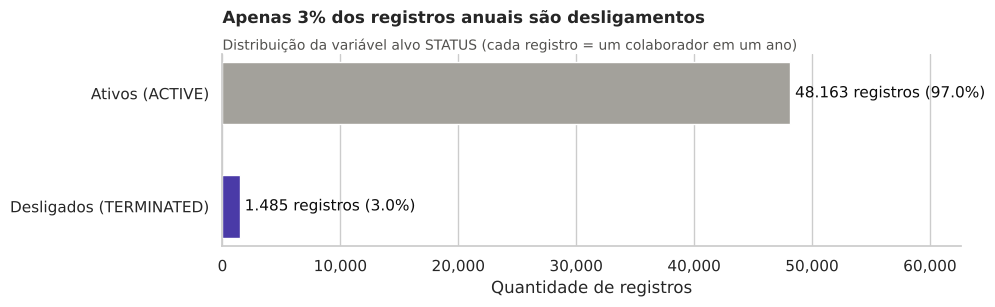

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ordem = ['ACTIVE', 'TERMINATED']
cores = [COR_ATIVO, COR_DESLIGADO]
rotulos = ['Ativos (ACTIVE)', 'Desligados (TERMINATED)']
barras = ax.barh(rotulos, contagem_target[ordem].values, color=cores, height=0.55)
for barra, qtd, pct in zip(barras, contagem_target[ordem].values, proporcao_target[ordem].values):
    ax.text(barra.get_width() + 400, barra.get_y() + barra.get_height() / 2,
            f'{qtd:,} registros ({pct:.1f}%)'.replace(',', '.'), va='center', fontsize=11, color='#0b0b0b')
ax.set_xlim(0, contagem_target.max() * 1.3)
ax.invert_yaxis()
ax.grid(axis='y', visible=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
estilizar(ax, 'Apenas 3% dos registros anuais são desligamentos',
          'Distribuição da variável alvo STATUS (cada registro = um colaborador em um ano)',
          xlabel='Quantidade de registros', ylabel='')
plt.tight_layout()
plt.show()

> **Observação sobre a Distribuição da Variável Alvo:**
> * **Ativos (`ACTIVE`)**: $48.163$ registros ($97,01\%$)
> * **Desligados (`TERMINATED`)**: $1.485$ registros ($2,99\%$)
>
> A variável alvo apresenta um **desbalanceamento severo de classes**. Como cada linha é um colaborador em um ano, os $3\%$ funcionam como uma taxa anual de desligamento, que variou entre $2,0\%$ e $4,9\%$ ao longo da década. Olhando por pessoa, $1.485$ dos $6.284$ colaboradores ($23,6\%$) saíram em algum momento dos 10 anos.
> (Os ativos passaram de 48.168 para 48.163 com a remoção das 5 duplicidades no Data Quality Report.)
>
> Em etapas futuras de modelagem preditiva, será necessário utilizar métricas adequadas (como Precision, Recall, F1-Score e PR-AUC) e possíveis técnicas de balanceamento.

### 4.2 Seleção e Justificativa dos Atributos

Para investigar os fatores associados ao desligamento, selecionamos os seguintes atributos:

| Atributo | Tipo | Por que investigar? (Justificativa) |
| :--- | :--- | :--- |
| **`age` (Idade)** | Numérica | Colaboradores mais jovens podem apresentar maior rotatividade voluntária no início da carreira, enquanto colaboradores mais velhos concentram desligamentos por aposentadoria. |
| **`length_of_service` (Tempo de Empresa)** | Numérica | Permite avaliar a curva de retenção: se os desligamentos ocorrem na fase de adaptação (novatos) ou por maturidade na organização (veteranos). |
| **`BUSINESS_UNIT` (Unidade de Negócio)** | Categórica | Unidades corporativas (`HEADOFFICE`) e operacionais (`STORES`) possuem dinâmicas, pressões de trabalho e estabilidade completamente distintas. |
| **`department_name` (Departamento)** | Categórica | Permite identificar se setores específicos (ex: Atendimento ao Cliente, TI, Produção) enfrentam gargalos de clima, retenção ou liderança. |
| **`termreason_desc` (Motivo do Desligamento)** | Categórica | Atributo indispensável para discriminar a natureza real da saída (`Resignation`, `Retirement`, `Layoff`). |

### 4.3 Investigação dos Atributos

Seguindo estritamente a metodologia exigida na atividade, cada análise está registrada no formato:
* **Pergunta**: O que queremos descobrir?
* **Gráfico**: Qual gráfico foi utilizado?
* **Observação**: O que realmente apareceu nos dados?
* **Hipótese**: O que esse resultado pode indicar?

---
#### Análise 1: Numérica × Variável Alvo
##### Comportamento da Idade (`age`) e do Tempo de Serviço (`length_of_service`) por Status

In [13]:
print('=== Idade por status ===')
print(df_eda.groupby('STATUS')['age'].describe().round(2))
print('\n=== Tempo de empresa (anos) por status ===')
print(df_eda.groupby('STATUS')['length_of_service'].describe().round(2))

=== Idade por status ===
              count   mean    std   min   25%   50%   75%   max
STATUS                                                         
ACTIVE      48163.0  41.79  12.16  19.0  31.0  42.0  52.0  64.0
TERMINATED   1485.0  51.46  16.52  19.0  34.0  60.0  65.0  65.0

=== Tempo de empresa (anos) por status ===
              count   mean   std  min  25%   50%   75%   max
STATUS                                                      
ACTIVE      48163.0  10.41  6.31  0.0  5.0  10.0  15.0  26.0
TERMINATED   1485.0  11.36  6.74  0.0  7.0  13.0  13.0  25.0


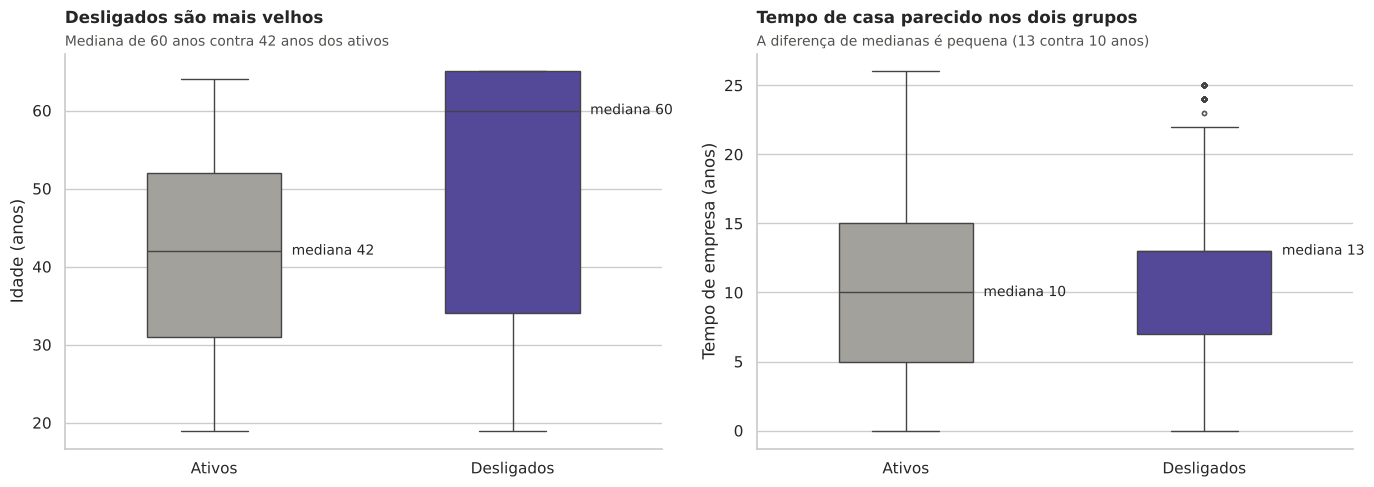

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
paleta_status = {'ACTIVE': COR_ATIVO, 'TERMINATED': COR_DESLIGADO}

for ax, col, nome in zip(axes, ['age', 'length_of_service'], ['Idade (anos)', 'Tempo de empresa (anos)']):
    sns.boxplot(data=df_eda, x='STATUS', y=col, order=['ACTIVE', 'TERMINATED'], hue='STATUS',
                palette=paleta_status, width=0.45, ax=ax, legend=False,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})
    ax.set_xticks([0, 1], ['Ativos', 'Desligados'])
    medianas = df_eda.groupby('STATUS')[col].median()
    for i, status in enumerate(['ACTIVE', 'TERMINATED']):
        ax.text(i + 0.26, medianas[status], f'mediana {medianas[status]:.0f}', va='center', fontsize=10)
    ax.grid(axis='x', visible=False)

estilizar(axes[0], 'Desligados são mais velhos', 'Mediana de 60 anos contra 42 anos dos ativos', '', 'Idade (anos)')
estilizar(axes[1], 'Tempo de casa parecido nos dois grupos', 'A diferença de medianas é pequena (13 contra 10 anos)',
          '', 'Tempo de empresa (anos)')
plt.tight_layout()
plt.show()

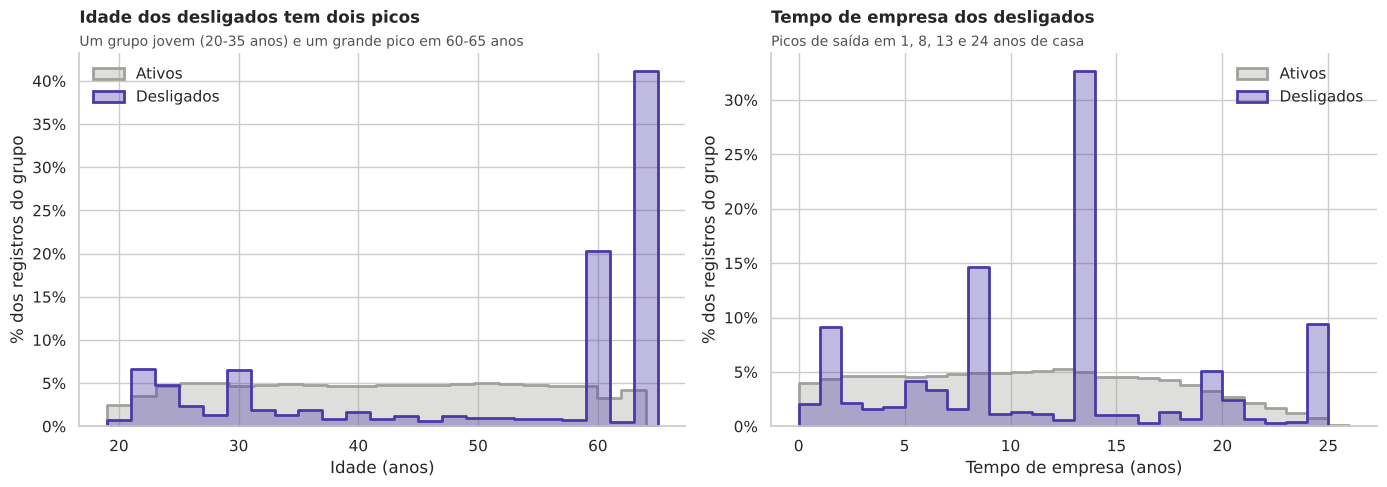

In [15]:
# Histogramas normalizados: cada grupo soma 100%, para comparar formas mesmo com tamanhos muito diferentes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, nome, largura in zip(axes, ['age', 'length_of_service'],
                                  ['Idade (anos)', 'Tempo de empresa (anos)'], [2, 1]):
    for status, cor, rotulo in [('ACTIVE', COR_ATIVO, 'Ativos'), ('TERMINATED', COR_DESLIGADO, 'Desligados')]:
        sns.histplot(df_eda[df_eda['STATUS'] == status][col], binwidth=largura, stat='percent',
                     element='step', fill=True, alpha=0.35, color=cor, label=rotulo, ax=ax, linewidth=2)
    ax.legend(frameon=False)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
estilizar(axes[0], 'Idade dos desligados tem dois picos',
          'Um grupo jovem (20-35 anos) e um grande pico em 60-65 anos', 'Idade (anos)', '% dos registros do grupo')
estilizar(axes[1], 'Tempo de empresa dos desligados',
          'Picos de saída em 1, 8, 13 e 24 anos de casa',
          'Tempo de empresa (anos)', '% dos registros do grupo')
plt.tight_layout()
plt.show()

##### Registro da Análise 1:
* **Pergunta**: Colaboradores desligados possuem padrão de idade e tempo de casa diferente dos colaboradores que permanecem ativos?
* **Gráfico**: Boxplots comparativos lado a lado e histogramas normalizados (em % de cada grupo) de `age` e `length_of_service` agrupados por `STATUS`.
* **Observação**:
  1. A média ($51,46$ anos) e a mediana ($60$ anos) de idade dos desligados são consideravelmente mais altas do que as dos ativos (média de $41,79$ anos e mediana de $42$ anos).
  2. A distribuição de idade dos desligados é nitidamente **bimodal**: há um pico expressivo aos $60$ e aos $65$ anos (aposentadorias) e uma concentração de saídas entre jovens ($20$ a $35$ anos).
  3. No tempo de empresa, os desligados têm picos em $1$, $8$, $13$ e $24$ anos de casa: o pico de $1$ ano vem principalmente dos pedidos de demissão e o de $13$ anos, das aposentadorias.
* **Hipótese**: O desligamento na organização é composto por dois perfis opostos: a saída natural programada por aposentadoria no topo da carreira (maior volume) e a evasão voluntária de jovens talentos nos primeiros anos de empresa.

---
#### Análise 2: Categórica × Variável Alvo
##### Impacto da Unidade de Negócio (`BUSINESS_UNIT`) e dos Departamentos no Desligamento

In [16]:
# Taxa de desligamento por unidade, separada por motivo (% dos registros de cada unidade)
taxa_bu = pd.crosstab(df_eda['BUSINESS_UNIT'], df_eda['termreason_desc'], normalize='index') * 100
print('=== Taxa de desligamento por unidade de negócio e motivo (%) ===')
print(taxa_bu.drop(columns='Not Applicable').round(2))
print('\n=== Quantidade de desligamentos por unidade e motivo ===')
print(pd.crosstab(df_desligados['BUSINESS_UNIT'], df_desligados['termreason_desc']))
print('\nRegistros por unidade:', df_eda['BUSINESS_UNIT'].value_counts().to_dict())

=== Taxa de desligamento por unidade de negócio e motivo (%) ===
termreason_desc  Layoff  Resignation  Retirement
BUSINESS_UNIT                                   
HEADOFFICE         0.00         0.17       11.62
STORES             0.44         0.78        1.67

=== Quantidade de desligamentos por unidade e motivo ===
termreason_desc  Layoff  Resignation  Retirement
BUSINESS_UNIT                                   
HEADOFFICE            0            1          68
STORES              215          384         817

Registros por unidade: {'STORES': 49063, 'HEADOFFICE': 585}


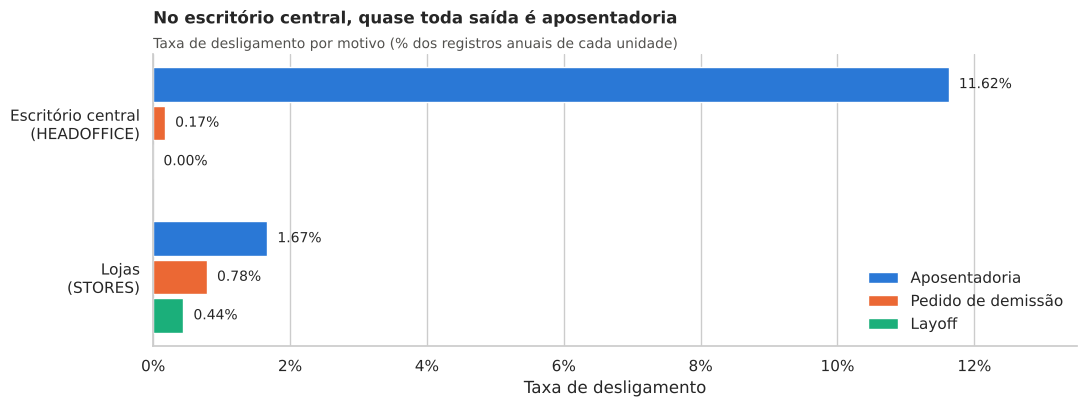

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.2))
motivos = ['Retirement', 'Resignation', 'Layoff']
unidades = ['HEADOFFICE', 'STORES']
altura = 0.25
for i, motivo in enumerate(motivos):
    posicoes = np.arange(len(unidades)) + (i - 1) * altura
    valores = taxa_bu.loc[unidades, motivo].values
    ax.barh(posicoes, valores, height=altura * 0.9, color=CORES_MOTIVO[motivo], label=NOMES_MOTIVO[motivo])
    for p, v in zip(posicoes, valores):
        ax.text(v + 0.15, p, f'{v:.2f}%', va='center', fontsize=10)
ax.set_yticks(range(len(unidades)), ['Escritório central\n(HEADOFFICE)', 'Lojas\n(STORES)'])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 13.5)
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, loc='lower right')
estilizar(ax, 'No escritório central, quase toda saída é aposentadoria',
          'Taxa de desligamento por motivo (% dos registros anuais de cada unidade)',
          'Taxa de desligamento', '')
plt.tight_layout()
plt.show()

=== Pedidos de demissão por departamento (todos) ===


,registros,pedidos,taxa
department_name,,,
Customer Service,7121,179,2.51
Dairy,8598,64,0.74
Processed Foods,5909,54,0.91
Bakery,8381,30,0.36
Meats,10268,29,0.28
Produce,8515,27,0.32
Store Management,271,1,0.37
HR Technology,64,1,1.56
Accounting,59,0,0.00


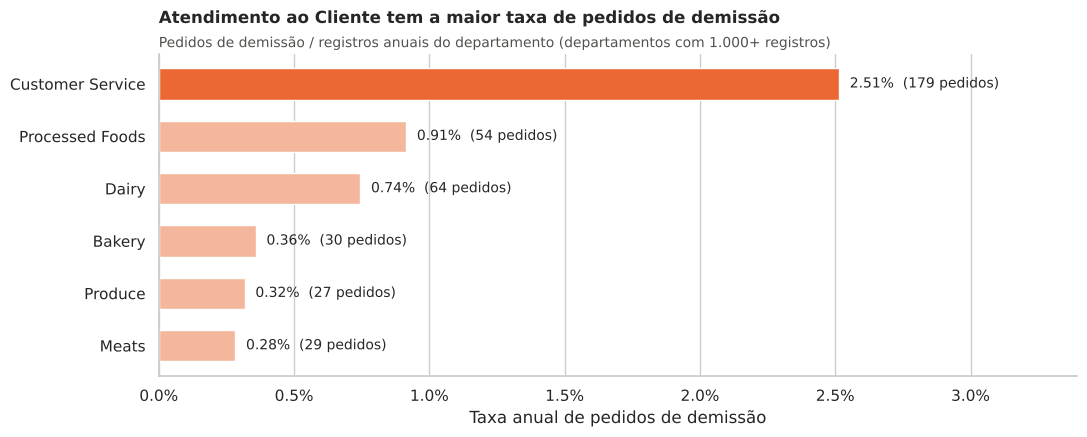

In [18]:
# Pedidos de demissão por departamento: usamos a TAXA (pedidos / registros do departamento),
# porque departamentos grandes naturalmente teriam mais pedidos em números absolutos.
dep = df_eda.groupby('department_name').agg(registros=('pedido_demissao', 'size'),
                                            pedidos=('pedido_demissao', 'sum'))
dep['taxa'] = dep['pedidos'] / dep['registros'] * 100
dep_relevantes = dep[dep['registros'] >= 1000].sort_values('taxa')   # só departamentos com volume suficiente
print('=== Pedidos de demissão por departamento (todos) ===')
display(dep.sort_values('pedidos', ascending=False).head(10).round(2))

fig, ax = plt.subplots(figsize=(11, 4.5))
cores_barras = [CORES_MOTIVO['Resignation'] if d == 'Customer Service' else '#f4b79c' for d in dep_relevantes.index]
ax.barh(dep_relevantes.index, dep_relevantes['taxa'], color=cores_barras, height=0.6)
for i, (taxa, qtd) in enumerate(zip(dep_relevantes['taxa'], dep_relevantes['pedidos'])):
    ax.text(taxa + 0.04, i, f'{taxa:.2f}%  ({qtd} pedidos)', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xlim(0, dep_relevantes['taxa'].max() * 1.35)
ax.grid(axis='y', visible=False)
estilizar(ax, 'Atendimento ao Cliente tem a maior taxa de pedidos de demissão',
          'Pedidos de demissão / registros anuais do departamento (departamentos com 1.000+ registros)',
          'Taxa anual de pedidos de demissão', '')
plt.tight_layout()
plt.show()

##### Registro da Análise 2:
* **Pergunta**: A unidade corporativa (`HEADOFFICE`) e as lojas operacionais (`STORES`) apresentam o mesmo comportamento e motivos de desligamento?
* **Gráfico**: Gráfico de barras com a taxa de desligamento por motivo em cada unidade (`pd.crosstab`) e gráfico de barras com a taxa de pedidos de demissão por departamento.
* **Observação**:
  1. O `HEADOFFICE` possui uma taxa percentual aparente de desligamento mais alta ($11,79\%$) do que as `STORES` ($2,89\%$). No entanto, no Head Office $98,6\%$ dos desligamentos foram por **Aposentadoria** ($68$ de $69$ casos) e houve apenas $1$ único pedido de demissão voluntária em 10 anos.
  2. Nas `STORES`, concentram-se $99,7\%$ de todos os pedidos de demissão voluntária ($384$ casos de $385$) e $100\%$ dos desligamentos involuntários/layoffs ($215$ casos).
  3. O setor de Atendimento ao Cliente (`Customer Service`) lidera com folga os pedidos de demissão ($179$ casos, correspondendo a quase metade de todas as demissões voluntárias da empresa) e tem a maior taxa anual de pedidos ($2,5\%$, quase 3 vezes a de qualquer outro departamento de loja).
* **Hipótese**: O escritório central retém talentos até a aposentadoria, enquanto as lojas físicas sofrem com a rotatividade operacional e a sobrecarga típica do atendimento ao cliente no varejo.

---
#### Análise 3: Numérica × Numérica
##### Relação entre Idade (`age`) e Tempo de Empresa (`length_of_service`) por Motivo de Saída

In [19]:
print('=== Idade e tempo de empresa por motivo de desligamento ===')
print(df_desligados.groupby('termreason_desc')[['age', 'length_of_service']]
      .agg(['mean', 'std', 'min', 'median', 'max']).round(2))

pedidos = df_desligados[df_desligados['termreason_desc'] == 'Resignation']
print(f"\nPedidos de demissão com até 35 anos de idade: {(pedidos['age'] <= 35).mean()*100:.0f}%")
print(f"Pedidos de demissão com até 5 anos de empresa: {(pedidos['length_of_service'] <= 5).mean()*100:.0f}%")

=== Idade e tempo de empresa por motivo de desligamento ===
                   age                    ... length_of_service               
                  mean    std min median  ...               std min median max
termreason_desc                           ...                                 
Layoff           40.80  13.60  20   39.0  ...              7.29   1   11.0  25
Resignation      30.10   9.60  19   29.0  ...              4.70   0    4.0  22
Retirement       63.34   2.36  60   65.0  ...              5.12   8   13.0  25

[3 rows x 10 columns]

Pedidos de demissão com até 35 anos de idade: 78%
Pedidos de demissão com até 5 anos de empresa: 68%


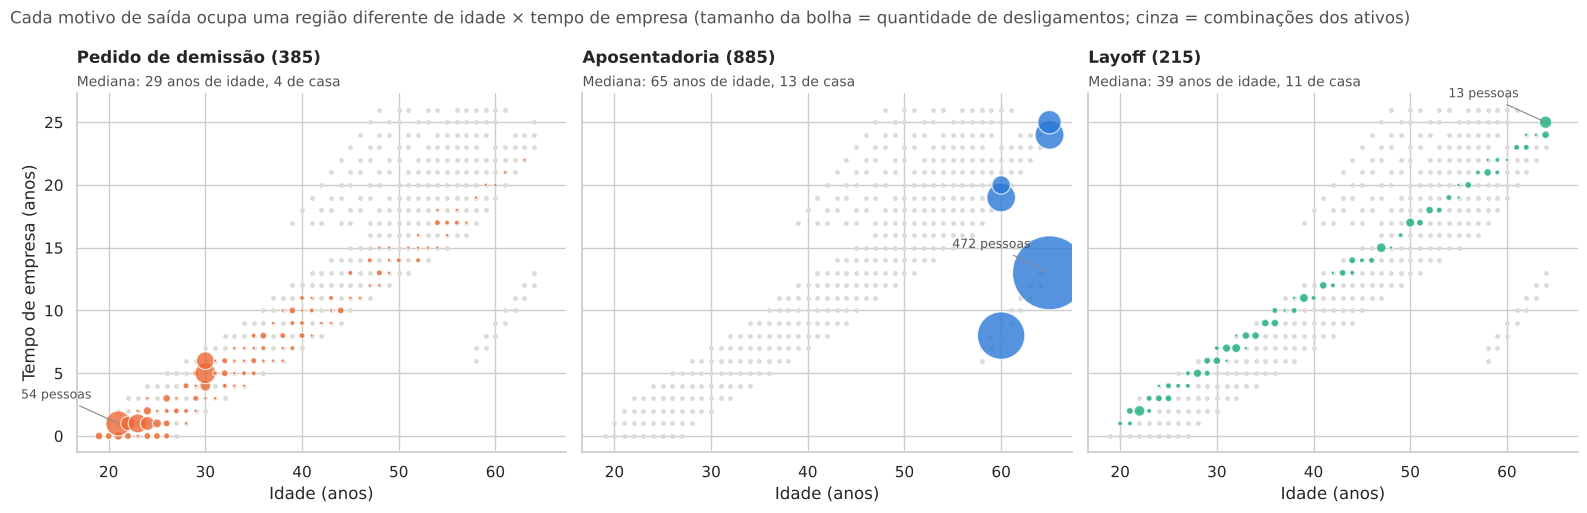

In [20]:
# Small multiples: um painel por motivo, todos com os mesmos eixos.
# Idade e tempo de empresa são números inteiros, então muitas pessoas caem exatamente no mesmo ponto.
# Para não esconder isso, o TAMANHO de cada bolha é proporcional à quantidade de desligamentos naquele ponto.
# Ao fundo (cinza claro), as combinações de idade e tempo de casa dos colaboradores ativos, como referência.
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
ativos_pontos = df_eda[df_eda['STATUS'] == 'ACTIVE'].groupby(['age', 'length_of_service']).size().reset_index()
for ax, motivo in zip(axes, ['Resignation', 'Retirement', 'Layoff']):
    ax.scatter(ativos_pontos['age'], ativos_pontos['length_of_service'], s=6, color='#dddbd5', zorder=1)
    sub = df_desligados[df_desligados['termreason_desc'] == motivo]
    pontos = sub.groupby(['age', 'length_of_service']).size().reset_index(name='qtd')
    ax.scatter(pontos['age'], pontos['length_of_service'], s=pontos['qtd'] * 6, color=CORES_MOTIVO[motivo],
               edgecolor='white', linewidth=0.8, alpha=0.8, zorder=2)
    maior = pontos.loc[pontos['qtd'].idxmax()]
    ax.annotate(f"{int(maior.qtd)} pessoas", (maior.age, maior.length_of_service), xytext=(-70, 18),
                textcoords='offset points', fontsize=9, color='#52514e',
                arrowprops=dict(arrowstyle='-', color='#8a8883', lw=0.8))
    estilizar(ax, f'{NOMES_MOTIVO[motivo]} ({len(sub)})',
              f'Mediana: {sub.age.median():.0f} anos de idade, {sub.length_of_service.median():.0f} de casa',
              'Idade (anos)', 'Tempo de empresa (anos)' if motivo == 'Resignation' else '')
fig.suptitle('Cada motivo de saída ocupa uma região diferente de idade × tempo de empresa '
             '(tamanho da bolha = quantidade de desligamentos; cinza = combinações dos ativos)', x=0.01, ha='left', fontsize=12, color='#52514e')
plt.tight_layout()
plt.show()

##### Registro da Análise 3:
* **Pergunta**: Como a combinação entre idade e tempo de serviço discrimina os diferentes motivos de saída da organização?
* **Gráfico**: Scatterplots (`age` vs `length_of_service`), um painel por motivo de saída, com o tamanho da bolha indicando a quantidade de desligamentos e os ativos ao fundo como referência.
* **Observação**:
  1. O gráfico mostra três regiões bem diferentes (com alguma sobreposição):
     * **Pedidos de Demissão (`Resignation`)**: Concentrados no quadrante inferior esquerdo: $78\%$ têm até $35$ anos (mediana $29$ anos) e $68\%$ têm até $5$ anos de casa (mediana $4$ anos), mas há casos até $63$ anos.
     * **Aposentadorias (`Retirement`)**: Acontecem somente aos $60$ anos ($294$ casos) ou aos $65$ anos ($591$ casos), com tempo de empresa de $8$ a $25$ anos (mediana $13$ anos).
     * **Demissões Involuntárias (`Layoff`)**: Dispersos em uma faixa ampla de idade ($20$ a $64$ anos) e tempo de casa ($1$ a $25$ anos).
* **Hipótese**: A demissão voluntária é um fenômeno concentrado na adaptação inicial de jovens colaboradores, enquanto a aposentadoria é um ciclo previdenciário natural e os layoffs foram ações pontuais da organização.

---
#### Análise 4: Correlação Multivariada (Heatmap)
##### Matriz de Correlação Linear das Variáveis Numéricas

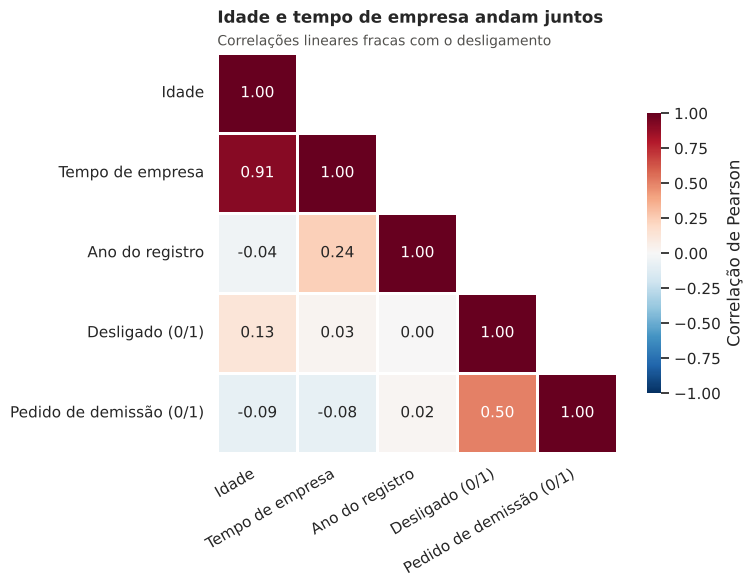

In [21]:
# Só entram variáveis realmente numéricas. store_name ficou de fora: é um código de loja,
# e a correlação de Pearson com um código não tem significado.
vars_corr = ['age', 'length_of_service', 'STATUS_YEAR', 'desligado', 'pedido_demissao']
corr_matrix = df_eda[vars_corr].corr()
nomes = ['Idade', 'Tempo de empresa', 'Ano do registro', 'Desligado (0/1)', 'Pedido de demissão (0/1)']

mascara = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # mostra só a metade inferior (sem repetição)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor='white', square=True, xticklabels=nomes, yticklabels=nomes,
            cbar_kws={'shrink': 0.7, 'label': 'Correlação de Pearson'}, ax=ax)
ax.grid(False)
plt.xticks(rotation=30, ha='right')
estilizar(ax, 'Idade e tempo de empresa andam juntos', 'Correlações lineares fracas com o desligamento')
plt.tight_layout()
plt.show()

##### Registro da Análise 4:
* **Pergunta**: Quais variáveis numéricas apresentam maior correlação linear entre si e com a ocorrência de desligamento?
* **Gráfico**: Heatmap de Correlação Linear de Pearson (`sns.heatmap`) com anotações numéricas. Retiramos o `store_name`, que é apenas o código da loja, e incluímos o pedido de demissão como variável 0/1.
* **Observação**:
  1. A correlação entre idade (`age`) e tempo de serviço (`length_of_service`) é muito forte e positiva ($r = 0,91$), demonstrando forte estabilidade histórica.
  2. O ano do registro (`STATUS_YEAR`) correlaciona positivamente com o tempo de serviço ($r = 0,237$), refletindo o acompanhamento longitudinal da mesma força de trabalho ao longo de 10 anos.
  3. A correlação linear com o desligamento é baixa: $r = 0,13$ com a idade e $r = 0,03$ com o tempo de empresa, devido à distribuição bimodal dos desligamentos. Para o pedido de demissão, a correlação com a idade é negativa ($r = -0,09$).
* **Hipótese**: Modelos preditivos baseados em regras e árvores de decisão (Decision Tree, Random Forest, XGBoost) serão mais adequados do que regressões lineares simples.

---
#### Análise 5: Visualização Interativa com Plotly
##### Cargos que Concentram Cada Tipo de Desligamento

In [22]:
cargos = (df_eda.groupby(['job_title', 'termreason_desc']).size().unstack(fill_value=0)
          .drop(columns='Not Applicable'))
cargos['registros'] = df_eda.groupby('job_title').size()
cargos['total_saidas'] = cargos[['Retirement', 'Resignation', 'Layoff']].sum(axis=1)
top_cargos = cargos.sort_values('total_saidas', ascending=False).head(12)
print('=== Cargos com mais desligamentos ===')
display(top_cargos)

dados_plot = (top_cargos[['Retirement', 'Resignation', 'Layoff']].reset_index()
              .melt(id_vars='job_title', var_name='motivo', value_name='quantidade'))
dados_plot['registros'] = dados_plot['job_title'].map(top_cargos['registros'])
dados_plot['taxa_anual_%'] = (dados_plot['quantidade'] / dados_plot['registros'] * 100).round(2)
dados_plot['Motivo'] = dados_plot['motivo'].map(NOMES_MOTIVO)

fig = px.bar(
    dados_plot, y='job_title', x='quantidade', color='Motivo', orientation='h',
    color_discrete_map={NOMES_MOTIVO[k]: v for k, v in CORES_MOTIVO.items()},
    category_orders={'job_title': top_cargos.index.tolist(),
                     'Motivo': ['Pedido de demissão', 'Aposentadoria', 'Layoff']},
    hover_data={'registros': ':,', 'taxa_anual_%': True, 'job_title': False},
    labels={'job_title': 'Cargo', 'quantidade': 'Quantidade de desligamentos'},
    title='<b>Caixas lideram os pedidos de demissão; açougueiros e repositores de hortifrúti, as aposentadorias</b>'
          '<br><sup>Desligamentos por cargo e motivo (12 cargos com mais saídas, 2006-2015)</sup>',
)
fig.update_layout(template='plotly_white', height=520, barmode='stack', legend_title_text='',
                  legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'), margin=dict(t=110))
fig.show()

=== Cargos com mais desligamentos ===


termreason_desc,Layoff,Resignation,Retirement,registros,total_saidas
job_title,,,,,
Meat Cutter,27,29,298,9983,354
Produce Clerk,16,27,289,8237,332
Cashier,67,179,2,6815,248
Dairy Person,46,64,80,8589,190
Baker,17,30,44,8096,91
Shelf Stocker,18,53,3,5620,74
Store Manager,6,1,24,271,31
Meats Manager,4,0,19,285,23
Bakery Manager,4,0,17,285,21


<Figura Plotly interativa>

##### Registro da Análise 5:
* **Pergunta**: Quais cargos concentram cada tipo de desligamento?
* **Gráfico**: Barras horizontais empilhadas e interativas com Plotly (`px.bar`), com quantidade, registros e taxa anual no *tooltip*.
* **Observação**:
  1. Os pedidos de demissão (`Resignation`) se concentram em cargos de entrada nas lojas: `Cashier` ($179$), `Dairy Person` ($64$) e `Shelf Stocker` ($53$). A taxa anual de pedidos dos caixas ($2,6\%$) é a maior entre os cargos com volume relevante.
  2. As aposentadorias também acontecem principalmente em cargos operacionais de loja, como `Meat Cutter` ($298$) e `Produce Clerk` ($289$), e não em cargos executivos.
* **Hipótese**: O desafio de retenção voluntária está na base operacional das lojas, principalmente nos caixas, exigindo planos de progressão para cargos de entrada. Já açougue e hortifrúti precisam de planejamento sucessório, porque perdem muitos profissionais experientes por aposentadoria.

---
#### Análise 6 (Aprofundamento): Análise Temporal dos Desligamentos (2006 a 2015)
##### Evolução Histórica dos Motivos de Saída ao Longo de 10 Anos

=== Desligamentos por ano e motivo ===
termreason_desc  Layoff  Resignation  Retirement
STATUS_YEAR                                     
2006                  0           12         122
2007                  0           25         137
2008                  0           26         138
2009                  0           18         124
2010                  0           29          94
2011                  0           69          41
2012                  0           76          54
2013                  0           49          56
2014                142           55          56
2015                 73           26          63


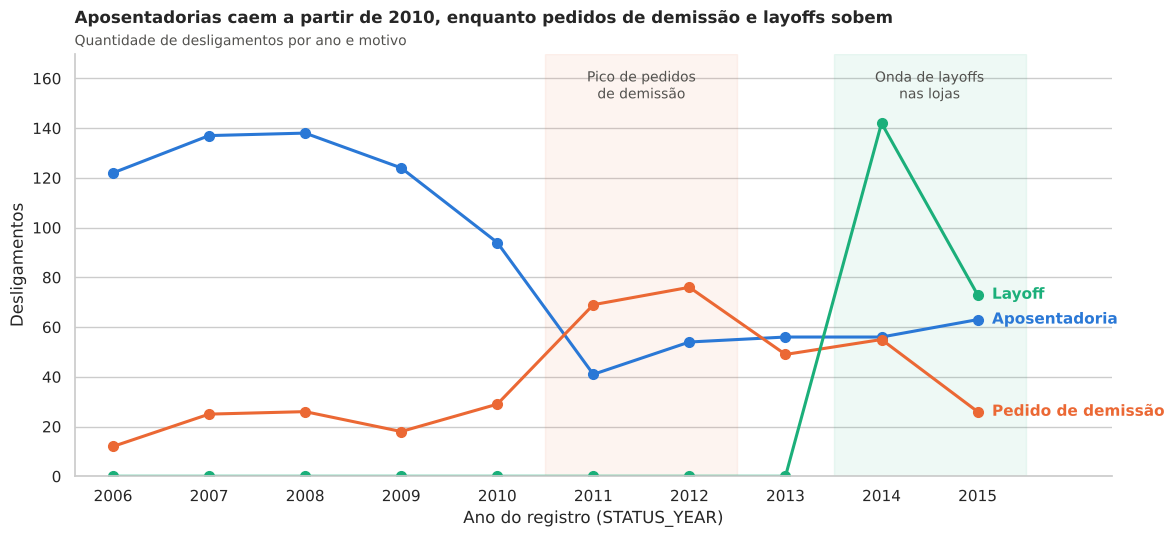

In [23]:
temporal = pd.crosstab(df_eda['STATUS_YEAR'], df_eda['termreason_desc']).drop(columns='Not Applicable')
print('=== Desligamentos por ano e motivo ===')
print(temporal)

fig, ax = plt.subplots(figsize=(12, 5.5))
for motivo in ['Retirement', 'Resignation', 'Layoff']:
    ax.plot(temporal.index, temporal[motivo], marker='o', markersize=7, linewidth=2.2,
            color=CORES_MOTIVO[motivo], label=NOMES_MOTIVO[motivo])
    ax.text(temporal.index[-1] + 0.15, temporal[motivo].iloc[-1], NOMES_MOTIVO[motivo],
            color=CORES_MOTIVO[motivo], va='center', fontsize=11, fontweight='bold')

ax.axvspan(2010.5, 2012.5, color=CORES_MOTIVO['Resignation'], alpha=0.07)
ax.text(2011.5, 152, 'Pico de pedidos\nde demissão', ha='center', fontsize=10, color='#52514e')
ax.axvspan(2013.5, 2015.5, color=CORES_MOTIVO['Layoff'], alpha=0.07)
ax.text(2014.5, 152, 'Onda de layoffs\nnas lojas', ha='center', fontsize=10, color='#52514e')
ax.set_xticks(temporal.index)
ax.set_xlim(2005.6, 2016.4)
ax.set_ylim(0, 170)
ax.grid(axis='x', visible=False)
estilizar(ax, 'Aposentadorias caem a partir de 2010, enquanto pedidos de demissão e layoffs sobem',
          'Quantidade de desligamentos por ano e motivo', 'Ano do registro (STATUS_YEAR)', 'Desligamentos')
plt.tight_layout()
plt.show()

In [24]:
layoffs = df_desligados[df_desligados['termreason_desc'] == 'Layoff']
print('Anos com layoff:', sorted(layoffs['STATUS_YEAR'].unique()))
print('Lojas com mais layoffs (2014 e 2015):')
print(layoffs['store_name'].value_counts().head(6).to_string())

Anos com layoff: [np.int64(2014), np.int64(2015)]
Lojas com mais layoffs (2014 e 2015):
store_name
11    39
20    31
13    30
39    24
14    21
27    17


##### Registro da Análise 6:
* **Pergunta**: Como o volume e os motivos de desligamento evoluíram ao longo da década analisada (2006 a 2015)?
* **Gráfico**: Gráfico de linhas por motivo ao longo dos anos, com destaque para os períodos de mudança.
* **Observação**:
  1. De $2006$ a $2009$, o padrão foi dominado por $122$ a $138$ aposentadorias por ano e poucas demissões voluntárias ($12$ a $26$). Em $2010$ as aposentadorias já caem para $94$.
  2. Em $2011$ e $2012$, os pedidos de demissão voluntária (`Resignation`) mais que dobraram, atingindo $69$ e $76$ casos, enquanto as aposentadorias caíram para $41$ e $54$.
  3. Em $2014$ e $2015$, ocorreram demissões em massa inéditas (`Layoff`), com $142$ desligamentos em 2014 e $73$ em 2015, concentrados em lojas físicas específicas (ex: lojas 11, 20, 13 e 39).
* **Hipótese**: Em 2011-2012 houve maior aquecimento de mercado ou pressão operacional no varejo, e em 2014-2015 a empresa executou um plano de reestruturação física com fechamento de filiais menos rentáveis.

### 4.4 Síntese e Descobertas Finais

Ao final desta primeira investigação exploratória (EDA), consolidamos as principais descobertas, hipóteses de negócio e direcionamentos para as próximas etapas:

---
#### 3 Descobertas Encontradas na EDA:

1. **Comportamento Bimodal da Rotatividade**:
   * O desligamento não é homogêneo: divide-se principalmente entre jovens profissionais (a maioria até $35$ anos) com pouco tempo de casa (mediana de $4$ anos) pedindo demissão voluntária (`Resignation`), e profissionais seniores (aos $60$ ou $65$ anos) com longa carreira se aposentando (`Retirement`).
2. **Eventos Críticos e Localizados de Layoff (2014-2015)**:
   * $100\%$ das $215$ demissões involuntárias (`Layoff`) ocorreram nos anos de 2014 e 2015 e afetaram exclusivamente as lojas físicas (`STORES`), com forte concentração em unidades específicas (Lojas 11, 20, 13 e 39).
3. **Abismo Cultural e Estrutural entre Head Office e Stores**:
   * O escritório corporativo (`HEADOFFICE`) registrou apenas $1$ único pedido de demissão voluntária em 10 anos e teve $98,6\%$ de suas saídas motivadas por aposentadoria. Em contrapartida, as lojas físicas concentram $99,7\%$ dos pedidos de demissão da empresa, com liderança absoluta do setor de `Customer Service` ($179$ demissões).

---
#### 2 Hipóteses de Negócio:

1. **Hipótese de Fuga de Jovens Talentos no Varejo Operacional**:
   * A ausência de planos de carreira rápidos, baixa atratividade de benefícios de entrada e o alto nível de estresse no atendimento levam colaboradores jovens a utilizarem as lojas apenas como ocupação temporária, deixando a empresa antes de completar 5 anos.
2. **Hipótese de Reestruturação Comercial e Fechamento de Filiais (2014-2015)**:
   * A onda de layoffs em 2014 e 2015 decorreu de decisões estratégicas de encerramento de lojas com baixa rentabilidade ou automação de processos, e não de avaliações individuais de desempenho.

---
#### 1 Descoberta Inesperada:

* **Predomínio Absoluto de Aposentadorias e Alta Fidelidade Histórica**:
  * Ao contrário do esperado em bases de turnover (onde normalmente predominam demissões por baixo desempenho ou insatisfação), **$59,6\%$ de todos os desligamentos na empresa foram por Aposentadoria aos 60 ou 65 anos**, revelando uma força de trabalho que historicamente permanecia na empresa até o fim da carreira. A partir de 2010, porém, as aposentadorias caem e os pedidos de demissão sobem.

---
#### 1 Pergunta que os Dados Ainda Não Permitiram Responder:

* **Qual foi o fator motivador para o salto nos pedidos de demissão voluntária em 2011-2012, e qual era o nível de satisfação salarial e de clima desses colaboradores?**
  * O conjunto de dados não possui variáveis de remuneração (salário, bônus, benefícios), horas extras, notas de avaliação de desempenho ou pesquisa de clima organizacional/entrevista de desligamento. Portanto, não é possível confirmar se as demissões voluntárias decorreram de defasagem salarial, conflitos de liderança ou propostas da concorrência.


---
#### O que a EDA muda nas próximas etapas:
Os três motivos de saída têm naturezas diferentes. A **aposentadoria** acontece sempre aos 60 ou 65 anos (é previsível só pela idade), o **layoff** é uma decisão da empresa concentrada em 2014-2015 e em poucas lojas, e o **pedido de demissão** depende do colaborador e é onde o RH pode agir. Por isso, na modelagem vamos prever **apenas o pedido de demissão**.

---
## 5. Feature Engineering e Exportação da Base Preparada

Fluxo da atividade: **Identificar → Classificar → Transformar → Criar → Validar → Documentar**.

**Novo alvo para a modelagem: `desligamento_voluntario`** (1 = o colaborador pediu demissão naquele ano). Escolhemos prever só o pedido de demissão porque, como vimos na EDA, a aposentadoria acontece sempre aos 60 ou 65 anos (é previsível só pela idade) e o layoff é uma decisão da empresa. O pedido de demissão é o único caso em que o RH pode agir para reter a pessoa.

**Colunas removidas por vazamento de dados:** `STATUS`, `termreason_desc`, `termtype_desc` e `terminationdate_key` contêm a resposta ou informação do futuro, e as outras datas já estão resumidas em `age` e `length_of_service`. `EmployeeID` e `STATUS_YEAR` continuam na base só como referência (o `EmployeeID` é usado para separar treino e teste), mas não entram no modelo.

In [25]:
df_fe = df_clean.copy()

# Alvo da modelagem: 1 = pediu demissão naquele ano
df_fe['desligamento_voluntario'] = (df_fe['termreason_desc'] == 'Resignation').astype(int)

# Remoção das colunas com vazamento de informação
colunas_vazamento = ['STATUS', 'termreason_desc', 'termtype_desc', 'terminationdate_key',
                     'recorddate_key', 'birthdate_key', 'orighiredate_key']
df_fe = df_fe.drop(columns=colunas_vazamento)

print('Colunas restantes:', df_fe.columns.tolist())
print('\nDistribuição do novo alvo:')
print(df_fe['desligamento_voluntario'].value_counts().to_string())
print(f"Proporção de pedidos de demissão: {df_fe['desligamento_voluntario'].mean()*100:.2f}%")

Colunas restantes: ['EmployeeID', 'age', 'length_of_service', 'city_name', 'department_name', 'job_title', 'store_name', 'gender_short', 'STATUS_YEAR', 'BUSINESS_UNIT', 'desligamento_voluntario']

Distribuição do novo alvo:
desligamento_voluntario
0    49263
1      385
Proporção de pedidos de demissão: 0.78%


### 5.1 Desafio 1 — Transformação de variáveis categóricas

**Passo 1 e 2 — Identificar e analisar as variáveis categóricas**

In [26]:
colunas_cat = df_fe.select_dtypes(include='object').columns.tolist()
print('Variáveis categóricas (texto):', colunas_cat)
print('store_name também é categórica, apesar de numérica (código da loja).\n')

for col in colunas_cat + ['store_name']:
    print(f'{col}: {df_fe[col].nunique()} categorias')

Variáveis categóricas (texto): ['city_name', 'department_name', 'job_title', 'gender_short', 'BUSINESS_UNIT']
store_name também é categórica, apesar de numérica (código da loja).

city_name: 40 categorias
department_name: 21 categorias
job_title: 47 categorias
gender_short: 2 categorias
BUSINESS_UNIT: 2 categorias
store_name: 46 categorias


In [27]:
# Análise detalhada das duas variáveis escolhidas
for col in ['department_name', 'BUSINESS_UNIT']:
    print(f'=== {col} ===')
    print('Categorias:', sorted(df_fe[col].unique()))
    print(df_fe[col].value_counts().to_string())
    print()

=== department_name ===
Categorias: ['Accounting', 'Accounts Payable', 'Accounts Receivable', 'Audit', 'Bakery', 'Compensation', 'Customer Service', 'Dairy', 'Employee Records', 'Executive', 'HR Technology', 'Information Technology', 'Investment', 'Labor Relations', 'Legal', 'Meats', 'Processed Foods', 'Produce', 'Recruitment', 'Store Management', 'Training']
department_name
Meats                     10268
Dairy                      8598
Produce                    8515
Bakery                     8381
Customer Service           7121
Processed Foods            5909
Store Management            271
Executive                   100
Recruitment                  72
HR Technology                64
Accounting                   59
Employee Records             44
Accounts Receivable          39
Labor Relations              34
Accounts Payable             34
Training                     30
Compensation                 24
Audit                        24
Investment                   24
Information Te

**Passo 3 — Tipo de cada variável (nominal ou ordinal)**

| Variável | Categorias | Tipo | Comentário |
| :-- | :-- | :-- | :-- |
| `department_name` | 21 | Nominal | Departamentos não têm ordem (Padaria não é "maior" que Açougue) |
| `BUSINESS_UNIT` | 2 | Nominal (binária) | Escritório central ou lojas |
| `job_title` | 47 | Nominal | Existe alguma hierarquia (ex.: Clerk → Manager → Director), mas ela não é comparável entre áreas diferentes |
| `gender_short` | 2 | Nominal (binária) | F ou M |
| `city_name` | 40 | Nominal | Equivale à loja (1 cidade por loja) |
| `store_name` | 46 | Nominal (código) | Número da loja |

Nenhuma variável categórica original da base tem ordem natural. A técnica de **Ordinal Encoding** será aplicada no Desafio 3, em uma faixa de tempo de empresa que criamos (lá a ordem existe: 0-2 anos < 3-5 anos < ...).

**Passo 4 — As 2 variáveis escolhidas**

Escolhemos `department_name` e `BUSINESS_UNIT` porque foram as variáveis categóricas que mais mostraram diferença no comportamento de saída durante a EDA (Análise 2).

In [28]:
# Passo 5 - Transformação com One-Hot Encoding
antes = df_fe.shape

# department_name: uma coluna 0/1 para cada departamento.
#   Mantemos todas as categorias (sem drop_first): modelos de árvore não sofrem com
#   multicolinearidade, e manter todas facilita interpretar a importância de cada departamento.
# BUSINESS_UNIT: binária, então drop_first=True gera uma única coluna (1 = loja, 0 = escritório).
df_fe = pd.get_dummies(df_fe, columns=['department_name'], prefix='dept', dtype=int)
df_fe = pd.get_dummies(df_fe, columns=['BUSINESS_UNIT'], prefix='unidade', drop_first=True, dtype=int)

print(f'Dimensões antes: {antes} | depois: {df_fe.shape}')
colunas_dept = [c for c in df_fe.columns if c.startswith('dept_')]
print(f'Colunas criadas para department_name: {len(colunas_dept)}')
print('Coluna criada para BUSINESS_UNIT:', [c for c in df_fe.columns if c.startswith('unidade_')])
display(df_fe[['unidade_STORES'] + colunas_dept[:6]].head())

Dimensões antes: (49648, 11) | depois: (49648, 31)
Colunas criadas para department_name: 21
Coluna criada para BUSINESS_UNIT: ['unidade_STORES']


,unidade_STORES,dept_Accounting,dept_Accounts Payable,dept_Accounts Receivable,dept_Audit,dept_Bakery,dept_Compensation
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0


In [29]:
# As demais categóricas também precisam virar números para o modelo.
# job_title e gender_short: One-Hot (nominais).
df_fe = pd.get_dummies(df_fe, columns=['job_title'], prefix='cargo', dtype=int)
df_fe = pd.get_dummies(df_fe, columns=['gender_short'], prefix='genero', drop_first=True, dtype=int)

# city_name e store_name NÃO entram como features. Motivos:
#   1. São a mesma informação (cada loja fica em uma única cidade);
#   2. Com 40 a 46 categorias e poucos pedidos de demissão por loja, o modelo tenderia a decorar
#      lojas específicas (overfitting) em vez de aprender padrões gerais;
#   3. Um modelo que depende do código da loja não funciona para lojas novas.
# Guardamos store_name temporariamente, porque ele é usado para criar uma feature no Desafio 3.
df_fe = df_fe.drop(columns=['city_name'])
print('Dimensões após codificar todas as categóricas:', df_fe.shape)

Dimensões após codificar todas as categóricas: (49648, 76)


**Entrega do Desafio 1**

| Variável | Tipo | Técnica | Justificativa |
| :-- | :-- | :-- | :-- |
| `department_name` | Nominal | One-Hot Encoding (todas as categorias) | Não há ordem entre departamentos; uma coluna por departamento permite ao modelo isolar setores críticos, como Customer Service |
| `BUSINESS_UNIT` | Nominal (binária) | One-Hot Encoding com `drop_first` (1 coluna) | Só duas categorias: uma coluna 0/1 já carrega toda a informação |

Também codificamos `job_title` e `gender_short` (One-Hot) e excluímos `city_name` e `store_name` como features, pelas razões comentadas no código.

### 5.2 Desafio 2 — Escalonamento das variáveis

**Passos 1 e 2 — Variáveis numéricas e suas escalas**

In [30]:
variaveis_continuas = ['age', 'length_of_service']
print('Variáveis numéricas contínuas:', variaveis_continuas)
display(df_fe[variaveis_continuas].describe().round(2))

Variáveis numéricas contínuas: ['age', 'length_of_service']


,age,length_of_service
count,49648.00,49648.00
mean,42.08,10.43
std,12.43,6.33
min,19.00,0.00
25%,31.00,5.00
50%,42.00,10.00
75%,53.00,15.00
max,65.00,26.00


Idade vai de 19 a 65 e tempo de empresa de 0 a 26. As escalas são diferentes, mas parecidas. As outras colunas são 0/1 (One-Hot).

**Passo 3 — O algoritmo do projeto é sensível à escala?**

Vamos usar **Árvore de Decisão, Random Forest e XGBoost** (Bloco 6).

**Resposta: não.** Os três são baseados em árvores, que fazem perguntas do tipo *"idade ≤ 30?"*. Elas só dependem da **ordem** dos valores, não da distância entre eles. Se a idade for padronizada, a árvore só muda o número de corte e separa as mesmas pessoas. Quem precisaria de escalonamento são algoritmos baseados em distância, como KNN, ou modelos lineares, como a regressão logística.

Mesmo assim, aplicamos o `StandardScaler` abaixo para **demonstrar** o efeito e comprovar que a ordem dos valores não muda.

In [31]:
from sklearn.preprocessing import StandardScaler

# Demonstração em uma cópia: a base exportada continua com os valores originais
df_escala_demo = df_fe[variaveis_continuas].copy()
scaler = StandardScaler()
df_escala_demo[['age_scaled', 'length_of_service_scaled']] = scaler.fit_transform(df_escala_demo[variaveis_continuas])

print('=== Antes x depois (10 primeiras linhas) ===')
display(df_escala_demo[['age', 'age_scaled', 'length_of_service', 'length_of_service_scaled']].head(10).round(3))

print('=== Resumo antes x depois ===')
display(df_escala_demo.describe().loc[['mean', 'std', 'min', 'max']].round(3))

# Prova de que a ORDEM não muda (por isso as árvores não são afetadas)
mesma_ordem = (df_escala_demo['age'].rank() == df_escala_demo['age_scaled'].rank()).all()
print(f'A ordem dos colaboradores por idade é a mesma antes e depois? {mesma_ordem}')

=== Antes x depois (10 primeiras linhas) ===


,age,age_scaled,length_of_service,length_of_service_scaled
0,52,0.799,17,1.038
1,53,0.879,18,1.196
2,54,0.959,19,1.354
3,55,1.040,20,1.512
4,56,1.120,21,1.670
5,57,1.201,22,1.828
6,58,1.281,23,1.987
7,59,1.362,24,2.145
8,60,1.442,25,2.303
9,61,1.523,26,2.461


=== Resumo antes x depois ===


,age,length_of_service,age_scaled,length_of_service_scaled
mean,42.077,10.435,-0.000,-0.000
std,12.426,6.325,1.000,1.000
min,19.000,0.000,-1.857,-1.650
max,65.000,26.000,1.845,2.461


A ordem dos colaboradores por idade é a mesma antes e depois? True


**Entrega do Desafio 2**

| Item | Resposta |
| :-- | :-- |
| Algoritmo escolhido | Árvore de Decisão, Random Forest e XGBoost |
| Sensível à escala? | Não: as divisões das árvores dependem só da ordem dos valores |
| Scaler demonstrado | `StandardScaler` (média 0, desvio padrão 1) |
| Variáveis escalonadas (demonstração) | `age`, `length_of_service` |
| Decisão final | **Não aplicar** o escalonamento na base exportada |
| Justificativa | Não muda o resultado das árvores e deixaria a base mais difícil de interpretar (idade -0,97 é menos clara que 30 anos) |

### 5.3 Desafio 3 — Criação de novas features

Criamos 3 features a partir de colunas que já existem, sempre ligadas ao que a EDA mostrou sobre o problema.

In [32]:
# Feature 1 - idade_admissao: idade com que a pessoa entrou na empresa
df_fe['idade_admissao'] = df_fe['age'] - df_fe['length_of_service']

# Feature 2 - faixa_tempo_casa (ordinal): fase do colaborador na empresa
#   Criamos a faixa em texto e depois aplicamos Ordinal Encoding, respeitando a ordem natural.
faixas = pd.cut(df_fe['length_of_service'], bins=[-1, 2, 5, 10, 100],
                labels=['0-2 anos', '3-5 anos', '6-10 anos', '11+ anos'])
mapa_faixa = {'0-2 anos': 0, '3-5 anos': 1, '6-10 anos': 2, '11+ anos': 3}
df_fe['faixa_tempo_casa'] = faixas.astype(str).map(mapa_faixa)

# Feature 3 - headcount_loja_ano: quantos colaboradores a loja tinha naquele ano
#   Usa só informações conhecidas no próprio ano (não usa o alvo), então não há vazamento.
df_fe['headcount_loja_ano'] = df_fe.groupby(['store_name', 'STATUS_YEAR'])['EmployeeID'].transform('count')

novas_features = ['idade_admissao', 'faixa_tempo_casa', 'headcount_loja_ano']
display(df_fe[['age', 'length_of_service', 'store_name', 'STATUS_YEAR'] + novas_features].head())

,age,length_of_service,store_name,STATUS_YEAR,idade_admissao,faixa_tempo_casa,headcount_loja_ano
0,52,17,35,2006,35,3,218
1,53,18,35,2007,35,3,199
2,54,19,35,2008,35,3,171
3,55,20,35,2009,35,3,143
4,56,21,35,2010,35,3,106


**Documentação de cada feature**

**Feature 1**
- **Nome:** `idade_admissao`
- **Fórmula:** `age - length_of_service`
- **Colunas utilizadas:** `age` e `length_of_service`
- **O que representa:** a idade com que o colaborador foi contratado.
- **Por que pode ajudar o modelo:** a EDA mostrou que os pedidos de demissão vêm de jovens no início da carreira. Quem entra muito jovem pode estar usando a loja como primeiro emprego temporário, enquanto quem entra mais velho tende a buscar estabilidade.

**Feature 2**
- **Nome:** `faixa_tempo_casa`
- **Fórmula:** faixas de `length_of_service`: 0-2 anos → 0, 3-5 anos → 1, 6-10 anos → 2, 11+ anos → 3 (Ordinal Encoding)
- **Colunas utilizadas:** `length_of_service`
- **O que representa:** a fase do colaborador na empresa (adaptação, consolidação, maturidade, veterano).
- **Por que pode ajudar o modelo:** 68% dos pedidos de demissão acontecem com até 5 anos de casa. Agrupar em fases torna esse padrão mais explícito e mais fácil de explicar ao RH.

**Feature 3**
- **Nome:** `headcount_loja_ano`
- **Fórmula:** contagem de `EmployeeID` agrupada por `store_name` e `STATUS_YEAR`
- **Colunas utilizadas:** `EmployeeID`, `store_name` e `STATUS_YEAR`
- **O que representa:** o tamanho da equipe da loja (ou do escritório) naquele ano.
- **Por que pode ajudar o modelo:** lojas pequenas e grandes têm dinâmicas diferentes (carga de trabalho, proximidade com a liderança, oportunidades internas). Diferente do código da loja, o tamanho é uma característica que generaliza para lojas novas.

**Passo 5 — Verificação dos resultados**

In [33]:
print('=== Estatísticas das novas features ===')
display(df_fe[novas_features].describe().round(2))
print('Valores ausentes criados:')
print(df_fe[novas_features].isnull().sum().to_string())

# Verificação de coerência: idade de admissão nunca pode ser menor que 14 anos (idade mínima legal de trabalho)
print(f"\nMenor idade de admissão: {df_fe['idade_admissao'].min()} anos")

=== Estatísticas das novas features ===


,idade_admissao,faixa_tempo_casa,headcount_loja_ano
count,49648.00,49648.00,49648.00
mean,31.64,2.10,227.86
std,7.17,1.07,130.55
min,19.00,0.00,1.00
25%,26.00,1.00,118.00
50%,31.00,2.00,211.00
75%,36.00,3.00,350.00
max,52.00,3.00,495.00


Valores ausentes criados:
idade_admissao        0
faixa_tempo_casa      0
headcount_loja_ano    0

Menor idade de admissão: 19 anos


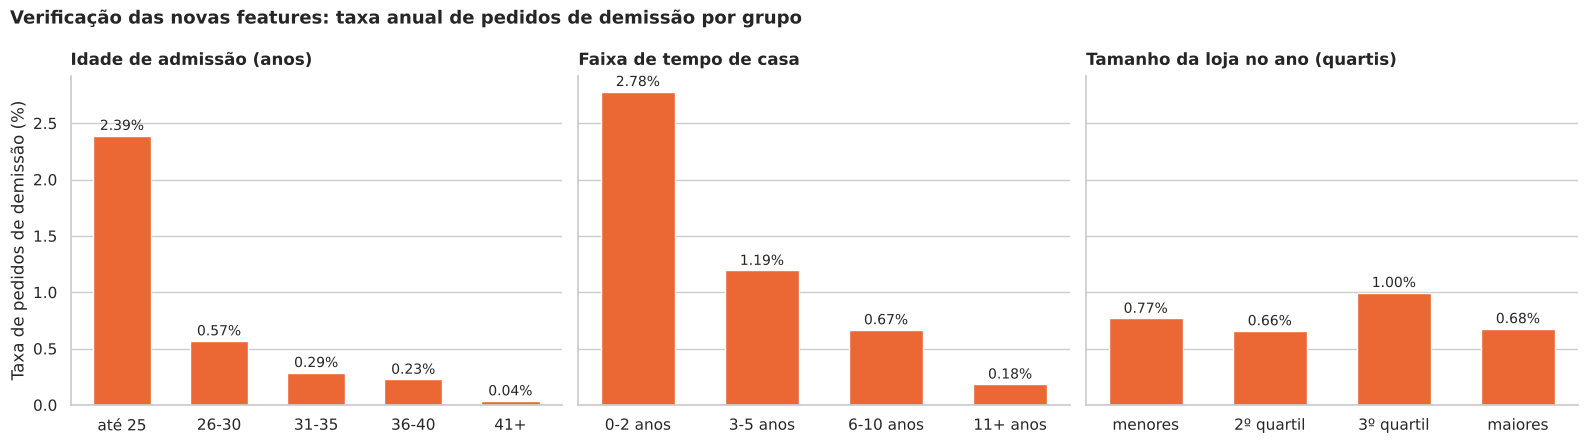

In [34]:
# As features carregam sinal? Taxa de pedidos de demissão em cada grupo
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

grupos = [
    (pd.cut(df_fe['idade_admissao'], [0, 25, 30, 35, 40, 60], labels=['até 25', '26-30', '31-35', '36-40', '41+']),
     'Idade de admissão (anos)'),
    (df_fe['faixa_tempo_casa'].map({v: k for k, v in mapa_faixa.items()}), 'Faixa de tempo de casa'),
    (pd.qcut(df_fe['headcount_loja_ano'], 4, labels=['menores', '2º quartil', '3º quartil', 'maiores']),
     'Tamanho da loja no ano (quartis)'),
]
for ax, (grupo, nome) in zip(axes, grupos):
    taxa = df_fe.groupby(grupo, observed=True)['desligamento_voluntario'].mean() * 100
    if nome.startswith('Faixa'):
        taxa = taxa.reindex(list(mapa_faixa.keys()))
    ax.bar(taxa.index.astype(str), taxa.values, color=CORES_MOTIVO['Resignation'], width=0.6)
    for i, v in enumerate(taxa.values):
        ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=10)
    ax.grid(axis='x', visible=False)
    estilizar(ax, nome, None, '', 'Taxa de pedidos de demissão (%)' if ax is axes[0] else '')
fig.suptitle('Verificação das novas features: taxa anual de pedidos de demissão por grupo',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Entrega do Desafio 3**

| Feature | Fórmula | Colunas utilizadas | O que representa | Por que pode ajudar |
| :-- | :-- | :-- | :-- | :-- |
| `idade_admissao` | `age - length_of_service` | `age`, `length_of_service` | Idade na contratação | Contratados muito jovens pedem demissão com muito mais frequência |
| `faixa_tempo_casa` | Faixas 0-2 / 3-5 / 6-10 / 11+ → 0 a 3 | `length_of_service` | Fase na empresa | A maioria das saídas voluntárias ocorre nos primeiros 5 anos |
| `headcount_loja_ano` | `count(EmployeeID)` por loja e ano | `EmployeeID`, `store_name`, `STATUS_YEAR` | Tamanho da equipe | Dinâmica de lojas grandes × pequenas, sem decorar a loja |

**Resultado da verificação:** nenhuma feature gerou valores ausentes e todos os valores são coerentes (a menor idade de admissão é 19 anos). As duas primeiras mostram um sinal forte: a taxa de pedidos de demissão cai à medida que a idade de admissão e o tempo de casa aumentam. Já `headcount_loja_ano` mostra pouca diferença entre os quartis. Mantivemos mesmo assim e conferimos a importância dela no Bloco 7.

### 5.4 Desafio 4 — IA Generativa como copiloto

**Passo 1 — Prompt utilizado**

Ferramenta: Claude (Anthropic), com o prompt da atividade preenchido com os dados do projeto:

```text
Atue como Cientista de Dados.
Meu projeto pertence ao setor de People Analytics (Recursos Humanos de uma rede varejista).
O objetivo do modelo é prever desligamento_voluntario (1 = o colaborador pediu demissão naquele ano).
As colunas disponíveis no dataset são:
EmployeeID, recorddate_key, birthdate_key, orighiredate_key, terminationdate_key, age,
length_of_service, city_name, department_name, job_title, store_name, gender_short,
termreason_desc, termtype_desc, STATUS_YEAR, STATUS, BUSINESS_UNIT
Sugira 5 novas features derivadas que possam ajudar o modelo a prever o target.
Para cada feature informe:
1. Nome;
2. Fórmula;
3. Colunas utilizadas;
4. O que representa;
5. Por que pode ser útil.
```

**Sugestões geradas pela IA**

1. `proporcao_vida_na_empresa = length_of_service / (age - 18)`: fração da vida adulta passada na empresa. Quem passou quase a vida toda na empresa tende a ser mais leal.
2. `anos_ate_aposentadoria = 65 - age`: quanto falta para a aposentadoria. Quem está perto de se aposentar raramente pede demissão.
3. `taxa_demissao_departamento`: média de `desligamento_voluntario` por `department_name`. Resume o risco histórico de cada setor.
4. `flag_novato = 1 se length_of_service <= 2`: colaborador em fase de adaptação.
5. `dias_ate_desligamento = terminationdate_key - recorddate_key`: tempo até a saída.

**Passo 2 — Análise das sugestões**

* **Sugestão 1:** dá para calcular, faz sentido para o negócio e não usa informação do futuro (a menor idade é 19, então nunca divide por zero). **Aprovada.**
* **Sugestão 2:** é só a idade "ao contrário". A árvore já consegue fazer isso usando `age`, então não acrescenta nada.
* **Sugestão 3:** usa o próprio alvo no cálculo. Feita com a base inteira, passaria a resposta do teste para o modelo. Rejeitada.
* **Sugestão 4:** repete a nossa `faixa_tempo_casa` do Desafio 3.
* **Sugestão 5:** usa a data de desligamento, que é informação do futuro (vazamento). Rejeitada.

As sugestões 3 e 5 mostram por que a IA é só um copiloto: elas parecem boas, mas usariam informações que o modelo não teria na hora de prever.

**Passo 3 — Sugestão escolhida: `proporcao_vida_na_empresa`**

Ela junta idade e tempo de casa numa medida de vínculo com a empresa. Um colaborador de 30 anos com 10 anos de casa passou quase toda a vida adulta ali, o que é bem diferente de alguém de 50 anos com os mesmos 10 anos de casa.

In [35]:
# Implementação da feature sugerida pela IA
df_fe['proporcao_vida_na_empresa'] = df_fe['length_of_service'] / (df_fe['age'] - 18)

# Verificação do resultado
print('=== Verificação da feature da IA ===')
display(df_fe['proporcao_vida_na_empresa'].describe().round(3))
print(f"Valores ausentes: {df_fe['proporcao_vida_na_empresa'].isnull().sum()}")
print(f"Valores infinitos: {np.isinf(df_fe['proporcao_vida_na_empresa']).sum()}")
print(f"Valores acima de 1 (impossível: mais tempo de casa que de vida adulta): "
      f"{(df_fe['proporcao_vida_na_empresa'] > 1).sum()}")

taxa_quartil = (df_fe.groupby(pd.qcut(df_fe['proporcao_vida_na_empresa'], 4,
                                      labels=['1º quartil (menor vínculo)', '2º quartil', '3º quartil',
                                              '4º quartil (maior vínculo)']), observed=True)
                ['desligamento_voluntario'].mean() * 100).round(2)
print('\nTaxa de pedidos de demissão (%) por quartil da proporção:')
print(taxa_quartil.to_string())

=== Verificação da feature da IA ===


count    49648.000
mean         0.406
std          0.133
min          0.000
25%          0.353
50%          0.444
75%          0.500
max          0.867
Name: proporcao_vida_na_empresa, dtype: float64

Valores ausentes: 0
Valores infinitos: 0
Valores acima de 1 (impossível: mais tempo de casa que de vida adulta): 0

Taxa de pedidos de demissão (%) por quartil da proporção:
proporcao_vida_na_empresa
1º quartil (menor vínculo)    1.69
2º quartil                    0.81
3º quartil                    0.47
4º quartil (maior vínculo)    0.00


**Resultado da implementação**

- A feature foi **mantida sem modificação na fórmula**. Nós apenas acrescentamos as verificações de ausentes, infinitos e valores acima de 1, que a IA não tinha sugerido.
- Todos os valores ficaram entre 0 e 1, sem ausentes nem infinitos.
- A taxa de pedidos de demissão cai de forma consistente entre os quartis: **1,69%** no quartil de menor vínculo, 0,81%, 0,47% e **0,00%** no quartil de maior vínculo. A feature carrega informação, e sua contribuição no modelo é medida na importância das features (Bloco 7).

### 5.5 Montagem e exportação da base preparada

A base final tem as features numéricas, as features criadas, as categóricas codificadas e o alvo, além do `EmployeeID` e do ano como referência.

In [36]:
# store_name foi usado apenas para criar headcount_loja_ano; agora pode sair
df_modelo = df_fe.drop(columns=['store_name'])

colunas_referencia = ['EmployeeID', 'STATUS_YEAR']   # não são features
alvo = 'desligamento_voluntario'
features = [c for c in df_modelo.columns if c not in colunas_referencia + [alvo]]

# Validações finais antes de exportar
assert df_modelo[features].isnull().sum().sum() == 0, 'Existem valores ausentes nas features'
assert all(pd.api.types.is_numeric_dtype(df_modelo[c]) for c in features), 'Existem features não numéricas'
assert not any(c in df_modelo.columns for c in colunas_vazamento), 'Coluna com vazamento na base'

print(f'Base final: {df_modelo.shape[0]:,} linhas x {df_modelo.shape[1]} colunas')
print(f'Features: {len(features)} | numéricas: 2 originais + 4 criadas | dummies: {len(features) - 6}')
print(f'Proporção do alvo: {df_modelo[alvo].mean()*100:.2f}%')

caminho_exportacao = 'dataset_preprocessado_aula2.csv'
df_modelo.to_csv(caminho_exportacao, index=False)
print(f'\nBase exportada para: {os.path.abspath(caminho_exportacao)}')
display(df_modelo.head())

Base final: 49,648 linhas x 79 colunas
Features: 76 | numéricas: 2 originais + 4 criadas | dummies: 70
Proporção do alvo: 0.78%

Base exportada para: /tmp/claude-0/-home-claude/1eec92d6-2305-5bf6-9cf6-5cf933032e98/scratchpad/work/dataset_preprocessado_aula2.csv


,EmployeeID,age,length_of_service,STATUS_YEAR,desligamento_voluntario,dept_Accounting,dept_Accounts Payable,dept_Accounts Receivable,dept_Audit,dept_Bakery,dept_Compensation,dept_Customer Service,dept_Dairy,dept_Employee Records,dept_Executive,dept_HR Technology,dept_Information Technology,dept_Investment,dept_Labor Relations,dept_Legal,dept_Meats,dept_Processed Foods,dept_Produce,dept_Recruitment,dept_Store Management,dept_Training,unidade_STORES,cargo_Accounting Clerk,cargo_Accounts Payable Clerk,cargo_Accounts Receiveable Clerk,cargo_Auditor,cargo_Baker,cargo_Bakery Manager,cargo_Benefits Admin,cargo_CEO,cargo_CHief Information Officer,cargo_Cashier,cargo_Compensation Analyst,cargo_Corporate Lawyer,cargo_Customer Service Manager,cargo_Dairy Manager,cargo_Dairy Person,"cargo_Director, Accounting","cargo_Director, Accounts Payable","cargo_Director, Accounts Receivable","cargo_Director, Audit","cargo_Director, Compensation","cargo_Director, Employee Records","cargo_Director, HR Technology","cargo_Director, Investments","cargo_Director, Labor Relations","cargo_Director, Recruitment","cargo_Director, Training","cargo_Exec Assistant, Finance","cargo_Exec Assistant, Human Resources","cargo_Exec Assistant, Legal Counsel","cargo_Exec Assistant, VP Stores",cargo_HRIS Analyst,cargo_Investment Analyst,cargo_Labor Relations Analyst,cargo_Legal Counsel,cargo_Meat Cutter,cargo_Meats Manager,cargo_Processed Foods Manager,cargo_Produce Clerk,cargo_Produce Manager,cargo_Recruiter,cargo_Shelf Stocker,cargo_Store Manager,cargo_Systems Analyst,cargo_Trainer,cargo_VP Finance,cargo_VP Human Resources,cargo_VP Stores,genero_M,idade_admissao,faixa_tempo_casa,headcount_loja_ano,proporcao_vida_na_empresa
0,1318,52,17,2006,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,35,3,218,0.500000
1,1318,53,18,2007,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,35,3,199,0.514286
2,1318,54,19,2008,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,35,3,171,0.527778
3,1318,55,20,2009,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,35,3,143,0.540541
4,1318,56,21,2010,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,35,3,106,0.552632


---
## 6. Treinamento de Modelos Preditivos

Seguindo o roteiro da Aula 3, carregamos a base preparada no Bloco 5, separamos as features (`X`) e o alvo (`y`), dividimos em treino e teste e treinamos os três modelos vistos em aula: **Árvore de Decisão, Random Forest e XGBoost**. Os três usam exatamente os mesmos dados, para a comparação ser justa.

### 6.1 Carregamento da base preparada

In [37]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier

SEED = 42   # garante que os resultados sejam reproduzíveis

# Carregamento do dataset preparado no Bloco 5 (equivalente à "Aula 2" do roteiro)
df_modelagem = pd.read_csv('dataset_preprocessado_aula2.csv')

# Separação em features (X) e target (y)
alvo = 'desligamento_voluntario'
X = df_modelagem.drop(columns=[alvo, 'EmployeeID', 'STATUS_YEAR'])
y = df_modelagem[alvo]
grupos = df_modelagem['EmployeeID']   # usado apenas para separar treino e teste por pessoa

print(f'X: {X.shape[0]:,} linhas x {X.shape[1]} features')
print(f'y: {y.sum()} pedidos de demissão ({y.mean()*100:.2f}%)')

X: 49,648 linhas x 76 features
y: 385 pedidos de demissão (0.78%)


### 6.2 Divisão treino e teste

Usamos 80% para treino e 20% para teste, com estratificação (a mesma proporção de pedidos de demissão nos dois conjuntos), como no roteiro da aula.

Mas tivemos um cuidado a mais: como cada colaborador aparece em vários anos, uma divisão comum poderia colocar a mesma pessoa no treino e no teste. Aí o modelo "reconheceria" a pessoa e o resultado do teste ficaria melhor do que a realidade (é o *Treino ≠ Prova* dos slides). Por isso usamos o `StratifiedGroupKFold`, que divide de forma estratificada e mantém todos os registros de um colaborador do mesmo lado.

In [38]:
divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
idx_treino, idx_teste = next(divisor.split(X, y, groups=grupos))

X_train, X_test = X.iloc[idx_treino], X.iloc[idx_teste]
y_train, y_test = y.iloc[idx_treino], y.iloc[idx_teste]
grupos_train = grupos.iloc[idx_treino]

print('=== DIVISÃO CONCLUÍDA ===')
print(f'Base de Treino: {X_train.shape[0]:,} amostras ({len(X_train)/len(X)*100:.0f}%)')
print(f'Base de Teste:  {X_test.shape[0]:,} amostras ({len(X_test)/len(X)*100:.0f}%)')
print(f'Taxa de pedidos de demissão no treino: {y_train.mean()*100:.2f}% ({y_train.sum()} casos)')
print(f'Taxa de pedidos de demissão no teste:  {y_test.mean()*100:.2f}% ({y_test.sum()} casos)')

colaboradores_em_comum = set(grupos.iloc[idx_treino]) & set(grupos.iloc[idx_teste])
print(f'Colaboradores presentes no treino E no teste: {len(colaboradores_em_comum)}')
assert len(colaboradores_em_comum) == 0

=== DIVISÃO CONCLUÍDA ===
Base de Treino: 39,718 amostras (80%)
Base de Teste:  9,930 amostras (20%)
Taxa de pedidos de demissão no treino: 0.78% (308 casos)
Taxa de pedidos de demissão no teste:  0.78% (77 casos)
Colaboradores presentes no treino E no teste: 0


### 6.3 Desbalanceamento

Existem 128 registros sem pedido de demissão para cada registro com pedido. Sem nenhum ajuste, o modelo aprende que é mais fácil responder sempre "não vai sair". Para evitar isso, demos mais peso à classe minoritária: `class_weight='balanced'` na Árvore e no Random Forest, e `scale_pos_weight` (negativos ÷ positivos do treino) no XGBoost.

In [39]:
peso_positivos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (negativos / positivos no treino): {peso_positivos:.1f}')

scale_pos_weight (negativos / positivos no treino): 128.0


### 6.4 Overfitting e underfitting

* **Underfitting:** o modelo é simples demais e não aprende nem o treino.
* **Overfitting:** o modelo decora o treino e erra em dados novos.

Para controlar isso, fazemos **validação cruzada dentro do treino** (dividimos o treino em 4 partes, treinamos em 3 e avaliamos na que sobrou) e comparamos o desempenho no treino com o da validação. A base de teste fica guardada só para a avaliação final do Bloco 7.

Como métrica usamos a **PR-AUC** (área sob a curva Precision-Recall), porque a acurácia fica alta mesmo para um modelo que não acerta nenhum pedido de demissão (mostramos isso no Bloco 7).

Abaixo variamos a profundidade da Árvore de Decisão para ver onde ela passa de underfitting para overfitting:

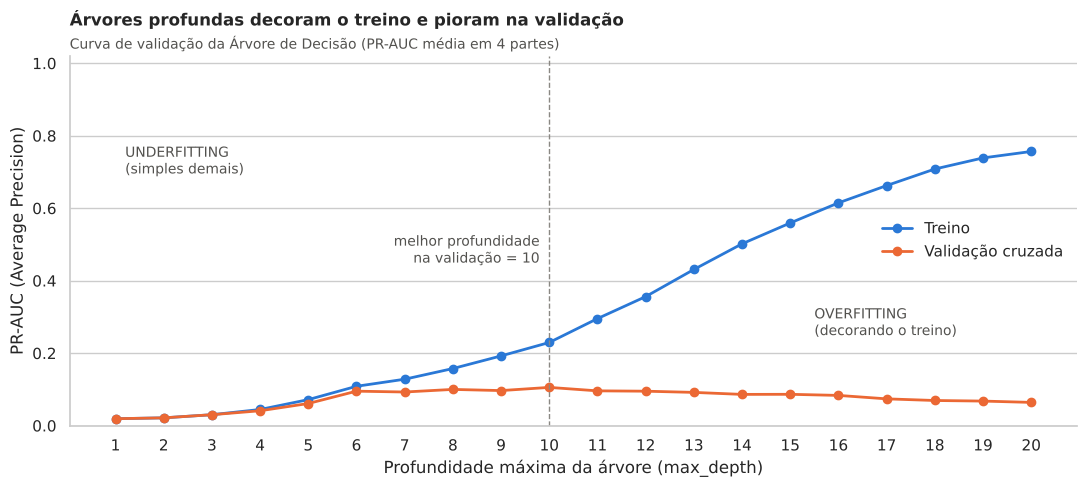

Melhor profundidade na validação: 10 | PR-AUC validação: 0.106 | PR-AUC treino nessa profundidade: 0.229


In [40]:
# Validação cruzada (4 partes) dentro do treino, sempre agrupada por colaborador
cv_treino = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
METRICA = 'average_precision'

# Curva de validação da Árvore de Decisão: profundidade de 1 a 20
profundidades = list(range(1, 21))
score_treino, score_validacao = [], []
for d in profundidades:
    s_tr, s_va = [], []
    for i_tr, i_va in cv_treino.split(X_train, y_train, groups=grupos_train):
        arvore = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=SEED)
        arvore.fit(X_train.iloc[i_tr], y_train.iloc[i_tr])
        s_tr.append(average_precision_score(y_train.iloc[i_tr], arvore.predict_proba(X_train.iloc[i_tr])[:, 1]))
        s_va.append(average_precision_score(y_train.iloc[i_va], arvore.predict_proba(X_train.iloc[i_va])[:, 1]))
    score_treino.append(np.mean(s_tr))
    score_validacao.append(np.mean(s_va))

melhor_d = profundidades[int(np.argmax(score_validacao))]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(profundidades, score_treino, marker='o', color=CORES_MODELO['Árvore de Decisão'], linewidth=2, label='Treino')
ax.plot(profundidades, score_validacao, marker='o', color=CORES_MOTIVO['Resignation'], linewidth=2, label='Validação cruzada')
ax.axvline(melhor_d, color='#8a8883', linestyle='--', linewidth=1)
ax.text(melhor_d - 0.2, 0.45, f'melhor profundidade\nna validação = {melhor_d}', fontsize=10, color='#52514e', ha='right')
ax.text(1.2, max(score_treino) * 0.92, 'UNDERFITTING\n(simples demais)', fontsize=10, color='#52514e')
ax.text(15.5, 0.25, 'OVERFITTING\n(decorando o treino)', fontsize=10, color='#52514e')
ax.set_xticks(profundidades)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc='center right')
ax.grid(axis='x', visible=False)
estilizar(ax, 'Árvores profundas decoram o treino e pioram na validação',
          'Curva de validação da Árvore de Decisão (PR-AUC média em 4 partes)',
          'Profundidade máxima da árvore (max_depth)', 'PR-AUC (Average Precision)')
plt.tight_layout()
plt.show()

print(f'Melhor profundidade na validação: {melhor_d} | PR-AUC validação: {max(score_validacao):.3f} '
      f'| PR-AUC treino nessa profundidade: {score_treino[melhor_d - 1]:.3f}')

**Leitura da curva:** até a profundidade 5 as duas curvas ficam baixas (underfitting). A validação melhora até a **profundidade 10** (PR-AUC de 0,106). Depois disso o treino continua subindo até 0,76, mas a validação cai para cerca de 0,06: a árvore começa a decorar o treino (overfitting). Por isso, na busca abaixo testamos profundidades até 10 e um número mínimo de registros por folha (`min_samples_leaf`).

### 6.5 Treinamento dos três modelos

Para cada modelo testamos algumas combinações de hiperparâmetros com o `GridSearchCV`, usando a mesma validação cruzada. Ele escolhe a combinação com a maior PR-AUC na validação e depois treina o modelo final com todo o treino. Escolhemos parâmetros que limitam a complexidade dos modelos (profundidade, tamanho mínimo das folhas, `learning_rate`) e deixamos as grades pequenas para o notebook rodar rápido.

In [41]:
modelos_e_grades = {
    'Árvore de Decisão': (
        DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        {'max_depth': [4, 6, 8, 10], 'min_samples_leaf': [20, 50, 100]},
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced', max_features='sqrt',
                               random_state=SEED, n_jobs=-1),
        {'max_depth': [6, 10, 14], 'min_samples_leaf': [10, 30]},
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=300, scale_pos_weight=peso_positivos, subsample=0.8, colsample_bytree=0.8,
                      eval_metric='logloss', random_state=SEED, n_jobs=-1),
        {'max_depth': [3, 4, 5], 'learning_rate': [0.03, 0.1], 'min_child_weight': [1, 5]},
    ),
}

modelos = {}
resultados_cv = []
for nome, (estimador, grade) in modelos_e_grades.items():
    busca = GridSearchCV(estimador, grade, scoring=METRICA, cv=cv_treino, n_jobs=1,
                         return_train_score=True, refit=True)
    busca.fit(X_train, y_train, groups=grupos_train)
    modelos[nome] = busca.best_estimator_
    i = busca.best_index_
    resultados_cv.append({
        'Modelo': nome,
        'Melhores hiperparâmetros': busca.best_params_,
        'PR-AUC treino (CV)': busca.cv_results_['mean_train_score'][i],
        'PR-AUC validação (CV)': busca.cv_results_['mean_test_score'][i],
        'Desvio validação': busca.cv_results_['std_test_score'][i],
    })
    print(f'{nome}: treinado | melhores hiperparâmetros: {busca.best_params_}')

tabela_cv = pd.DataFrame(resultados_cv).set_index('Modelo')
tabela_cv['Diferença treino - validação'] = tabela_cv['PR-AUC treino (CV)'] - tabela_cv['PR-AUC validação (CV)']
print('\n=== TODOS OS MODELOS FORAM TREINADOS COM SUCESSO! ===')
display(tabela_cv.round(3))

Árvore de Decisão: treinado | melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 50}
Random Forest: treinado | melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 10}
XGBoost: treinado | melhores hiperparâmetros: {'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 1}

=== TODOS OS MODELOS FORAM TREINADOS COM SUCESSO! ===


,Melhores hiperparâmetros,PR-AUC treino (CV),PR-AUC validação (CV),Desvio validação,Diferença treino - validação
Modelo,,,,,
Árvore de Decisão,"{'max_depth': 10, 'min_samples_leaf': 50}",0.165,0.120,0.034,0.045
Random Forest,"{'max_depth': 10, 'min_samples_leaf': 10}",0.227,0.135,0.040,0.092
XGBoost,"{'learning_rate': 0.03, 'max_depth': 5, 'min_c...",0.242,0.141,0.029,0.101


### 6.6 Diagnóstico de overfitting e underfitting

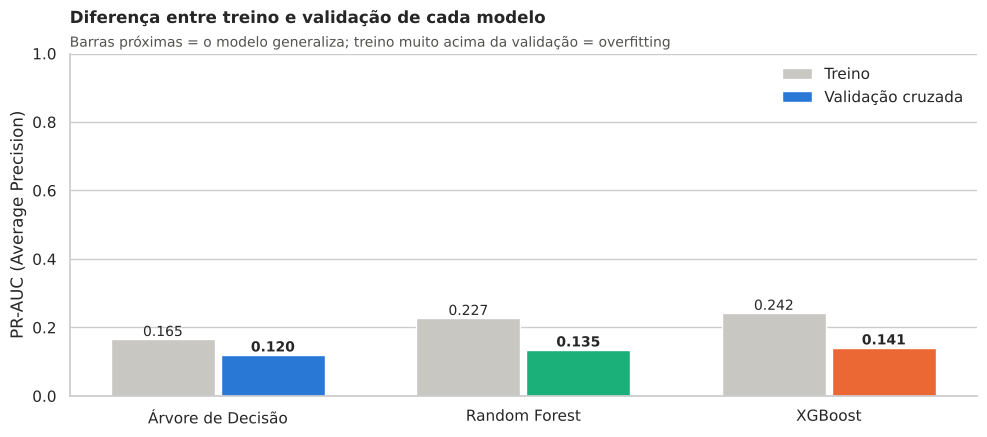

In [42]:
fig, ax = plt.subplots(figsize=(10, 4.5))
nomes_modelos = tabela_cv.index.tolist()
pos = np.arange(len(nomes_modelos))
ax.bar(pos - 0.18, tabela_cv['PR-AUC treino (CV)'], width=0.34, color='#c9c7c1', label='Treino')
ax.bar(pos + 0.18, tabela_cv['PR-AUC validação (CV)'], width=0.34,
       color=[CORES_MODELO[n] for n in nomes_modelos], label='Validação cruzada')
for p, (tr, va) in enumerate(zip(tabela_cv['PR-AUC treino (CV)'], tabela_cv['PR-AUC validação (CV)'])):
    ax.text(p - 0.18, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=10)
    ax.text(p + 0.18, va + 0.01, f'{va:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(pos, nomes_modelos)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
ax.grid(axis='x', visible=False)
estilizar(ax, 'Diferença entre treino e validação de cada modelo',
          'Barras próximas = o modelo generaliza; treino muito acima da validação = overfitting',
          '', 'PR-AUC (Average Precision)')
plt.tight_layout()
plt.show()

* A diferença entre treino e validação ficou entre 0,05 (Árvore) e 0,10 (XGBoost). Existe um pouco de overfitting, mas bem menor que o da árvore sem limite de profundidade (0,76 contra 0,06).
* Não há underfitting: a PR-AUC de validação (0,12 a 0,14) é de 15 a 18 vezes maior que a de um chute aleatório (0,0078).
* Os valores parecem baixos porque o problema é difícil: o modelo precisa acertar em qual ano a pessoa vai pedir demissão usando só idade, tempo de casa, cargo e local, sem dados de salário ou satisfação.
* O XGBoost teve a maior PR-AUC na validação (0,141), bem perto do Random Forest (0,135).

### 6.7 Previsões na base de teste (acurácia)

Agora usamos o `predict()` na base de teste, como no laboratório da aula ("Quem prevê melhor?").

,Modelo,Acertos,Total de testes,Acurácia
0,Árvore de Decisão,"8,215","9,930",82.73%
1,Random Forest,"9,037","9,930",91.01%
2,XGBoost,"8,861","9,930",89.23%


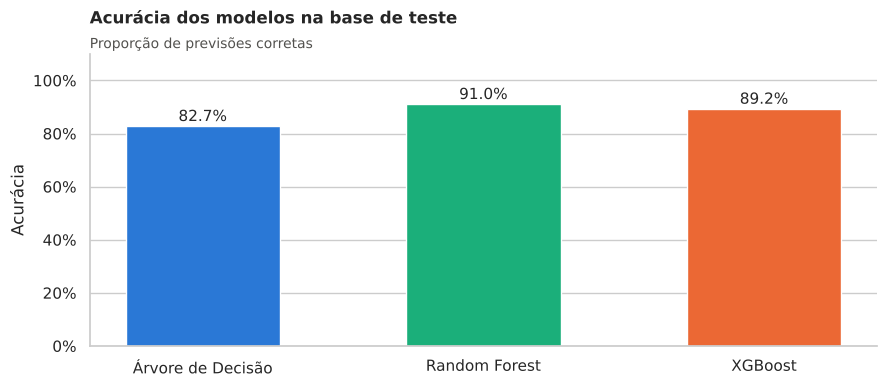

In [43]:
previsoes = {nome: modelo.predict(X_test) for nome, modelo in modelos.items()}
probabilidades = {nome: modelo.predict_proba(X_test)[:, 1] for nome, modelo in modelos.items()}

comparacao = pd.DataFrame({
    'Modelo': list(modelos.keys()),
    'Acertos': [(previsoes[n] == y_test.values).sum() for n in modelos],
    'Total de testes': [len(y_test)] * len(modelos),
    'Acurácia': [accuracy_score(y_test, previsoes[n]) for n in modelos],
})
display(comparacao.style.format({'Acurácia': '{:.2%}', 'Acertos': '{:,}', 'Total de testes': '{:,}'}))

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.bar(comparacao['Modelo'], comparacao['Acurácia'], color=[CORES_MODELO[n] for n in comparacao['Modelo']], width=0.55)
for b, v in zip(barras, comparacao['Acurácia']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='x', visible=False)
estilizar(ax, 'Acurácia dos modelos na base de teste', 'Proporção de previsões corretas', '', 'Acurácia')
plt.tight_layout()
plt.show()

O Random Forest teve a maior acurácia (91,0%), seguido do XGBoost (89,2%) e da Árvore (82,7%). Mas no Bloco 7 vamos ver que um modelo que **nunca** prevê pedido de demissão tem 99,2% de acurácia, mais que todos os nossos. Ou seja, olhando só a acurácia escolheríamos um modelo inútil.

> *"Se um modelo acertou 90% dos alunos, podemos afirmar que ele é bom?"* É isso que o Bloco 7 responde.

---
## 7. Avaliação dos Modelos

Fluxo da aula: **REALIDADE → PREVISÃO → COMPARAÇÃO → MÉTRICAS**. Todas as métricas são calculadas na base de teste, que não foi usada em nenhuma decisão até aqui.

### 7.1 Por que a acurácia sozinha engana

In [44]:
modelo_bobo = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
prev_bobo = modelo_bobo.predict(X_test)
print(f'Acurácia do modelo que nunca prevê pedido de demissão: {accuracy_score(y_test, prev_bobo):.2%}')
print(f'Pedidos de demissão que ele identificou: {((prev_bobo == 1) & (y_test == 1)).sum()} de {y_test.sum()}')

Acurácia do modelo que nunca prevê pedido de demissão: 99.22%
Pedidos de demissão que ele identificou: 0 de 77


O modelo "bobo" acerta mais de 99% e não encontra **nenhuma** pessoa que pediu demissão. Para o RH ele não serve para nada, então precisamos ver onde os modelos acertam e onde erram.

### 7.2 Matriz de confusão

* **VN (Verdadeiro Negativo):** não pediu demissão e o modelo acertou.
* **FP (Falso Positivo):** alarme falso, o modelo apontou alguém que ficou na empresa.
* **FN (Falso Negativo):** a pessoa saiu e o modelo não avisou. É o erro mais caro para o RH.
* **VP (Verdadeiro Positivo):** a pessoa saiu e o modelo avisou antes.

As matrizes abaixo usam o limiar padrão de 0,5.

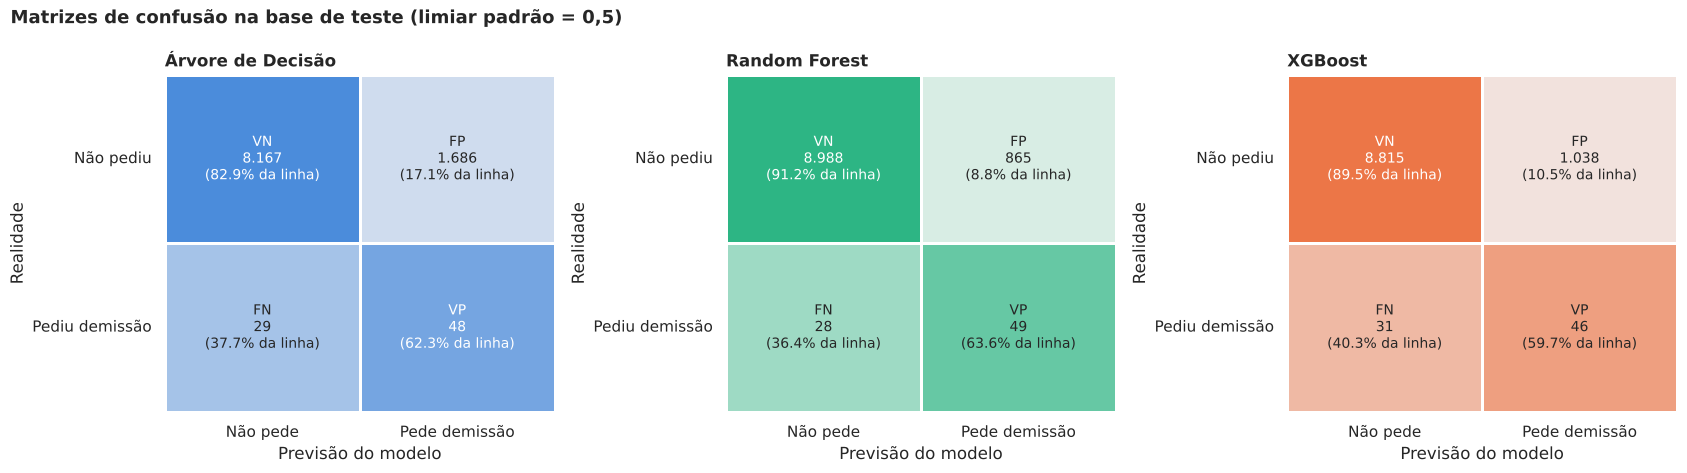

In [45]:
def desenhar_matriz(ax, y_real, y_prev, titulo, cor):
    """Matriz de confusão com valores absolutos e % da linha (realidade)."""
    cm = confusion_matrix(y_real, y_prev)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    rotulos = [['VN', 'FP'], ['FN', 'VP']]
    anot = np.array([[f'{rotulos[i][j]}\n{cm[i, j]:,}\n({cm_pct[i, j]:.1f}% da linha)'.replace(',', '.')
                      for j in range(2)] for i in range(2)])
    cmap = sns.light_palette(cor, as_cmap=True)
    sns.heatmap(cm_pct, annot=anot, fmt='', cmap=cmap, cbar=False, vmin=0, vmax=100,
                linewidths=2, linecolor='white', ax=ax, annot_kws={'fontsize': 10})
    ax.set_xticklabels(['Não pede', 'Pede demissão'])
    ax.set_yticklabels(['Não pediu', 'Pediu demissão'], rotation=0)
    ax.set_xlabel('Previsão do modelo')
    ax.set_ylabel('Realidade')
    ax.set_title(titulo, loc='left', fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, nome in zip(axes, modelos):
    desenhar_matriz(ax, y_test, previsoes[nome], nome, CORES_MODELO[nome])
fig.suptitle('Matrizes de confusão na base de teste (limiar padrão = 0,5)', x=0.01, ha='left',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Os três modelos encontram cerca de 60% dos pedidos de demissão (46 a 49 de 77), mas geram muitos alarmes falsos: de 865 a 1.686. Com o Random Forest, por exemplo, o RH teria que conversar com 914 pessoas para encontrar 49 que realmente sairiam.

### 7.3 Precision, Recall, F1-Score e ROC

* **Precision:** dos que o modelo apontou como risco, quantos realmente saíram? VP / (VP + FP)
* **Recall:** dos que saíram, quantos o modelo encontrou? VP / (VP + FN)
* **F1-Score:** equilíbrio entre Precision e Recall.
* **ROC-AUC:** chance de o modelo dar um risco maior para quem saiu do que para quem ficou (0,5 = chute, 1 = perfeito).
* **PR-AUC:** parecida com a ROC-AUC, mas focada na classe rara. Um chute aleatório teria PR-AUC de 0,008.

In [46]:
def calcular_metricas(y_real, y_prev, y_prob):
    return {
        'Acurácia': accuracy_score(y_real, y_prev),
        'Precision': precision_score(y_real, y_prev, zero_division=0),
        'Recall': recall_score(y_real, y_prev),
        'F1-Score': f1_score(y_real, y_prev),
        'ROC-AUC': roc_auc_score(y_real, y_prob),
        'PR-AUC': average_precision_score(y_real, y_prob),
    }

tabela_metricas = pd.DataFrame({nome: calcular_metricas(y_test, previsoes[nome], probabilidades[nome])
                                for nome in modelos}).T
tabela_metricas.loc['Modelo bobo (sempre "não")'] = calcular_metricas(y_test, prev_bobo, np.zeros(len(y_test)))
display(tabela_metricas.round(3))

,Acurácia,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Árvore de Decisão,0.827,0.028,0.623,0.053,0.780,0.160
Random Forest,0.910,0.054,0.636,0.099,0.851,0.186
XGBoost,0.892,0.042,0.597,0.079,0.847,0.179
"Modelo bobo (sempre ""não"")",0.992,0.000,0.000,0.000,0.500,0.008


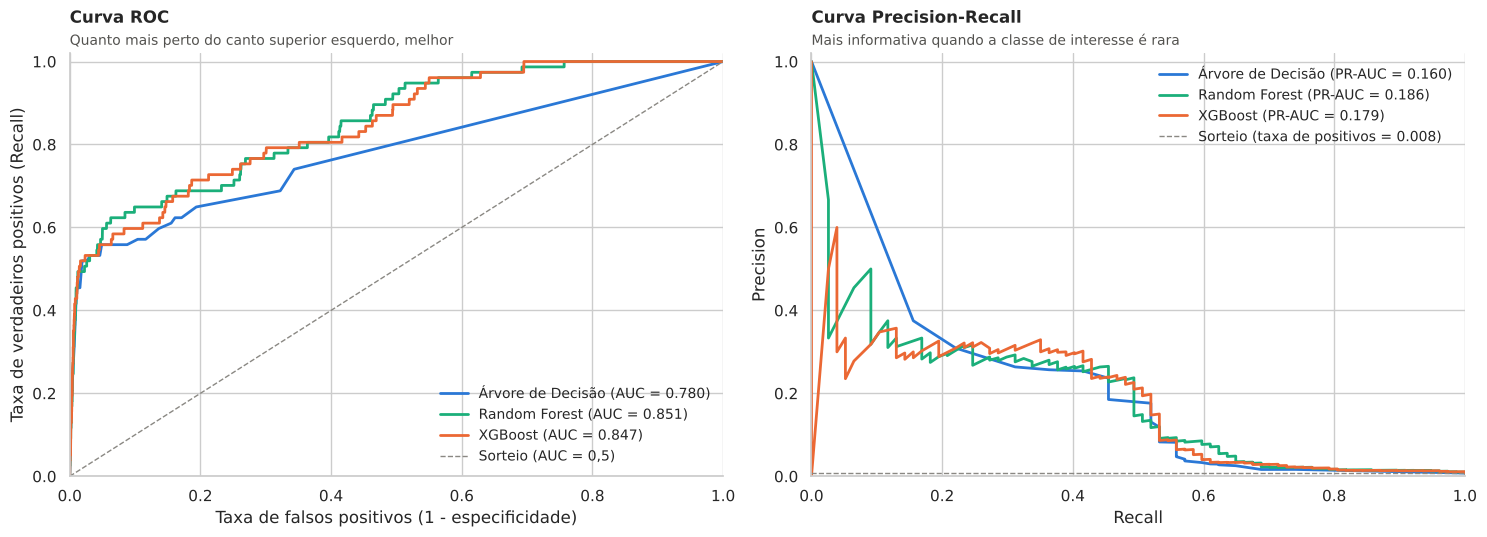

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for nome in modelos:
    fpr, tpr, _ = roc_curve(y_test, probabilidades[nome])
    axes[0].plot(fpr, tpr, color=CORES_MODELO[nome], linewidth=2,
                 label=f"{nome} (AUC = {tabela_metricas.loc[nome, 'ROC-AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, probabilidades[nome])
    axes[1].plot(rec, prec, color=CORES_MODELO[nome], linewidth=2,
                 label=f"{nome} (PR-AUC = {tabela_metricas.loc[nome, 'PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='#8a8883', linewidth=1, label='Sorteio (AUC = 0,5)')
axes[1].axhline(y_test.mean(), linestyle='--', color='#8a8883', linewidth=1,
                label=f'Sorteio (taxa de positivos = {y_test.mean():.3f})')
estilizar(axes[0], 'Curva ROC', 'Quanto mais perto do canto superior esquerdo, melhor',
          'Taxa de falsos positivos (1 - especificidade)', 'Taxa de verdadeiros positivos (Recall)')
estilizar(axes[1], 'Curva Precision-Recall', 'Mais informativa quando a classe de interesse é rara',
          'Recall', 'Precision')
for ax in axes:
    ax.legend(frameon=False, loc='lower right' if ax is axes[0] else 'upper right', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

* A acurácia do modelo bobo é a maior (99,2%), e ele é o único que não encontra ninguém.
* Na ROC-AUC, o Random Forest (0,851) e o XGBoost (0,847) ficaram bem à frente da Árvore de Decisão (0,780). Faz sentido com o que vimos nos slides: várias árvores juntas decidem melhor que uma só.
* A PR-AUC ficou entre 0,16 e 0,19, mais de 20 vezes melhor que um chute.
* Com o limiar de 0,5 o Recall é bom (60% a 64%), mas a Precision é muito baixa (3% a 5%).
* No teste, o Random Forest ficou um pouco à frente do XGBoost, mas a diferença é pequena (o teste tem só 77 pedidos de demissão). Por isso mantemos a escolha feita pela validação cruzada.

### 7.4 Modelo final e ajuste do limiar

O modelo final é escolhido pela PR-AUC na **validação cruzada** (seção 6.5), e não pelo teste, para o teste continuar sendo uma prova independente.

O limiar de 0,5 gera alarmes falsos demais. Para escolher um limiar melhor sem usar o teste, usamos o `cross_val_predict` no treino (cada registro é previsto por um modelo que não o viu) e pegamos o limiar com o maior F1. Depois aplicamos esse limiar no teste.

Modelo escolhido pela validação cruzada: XGBoost
Limiar que maximiza o F1 no treino (fora da amostra): 0.918


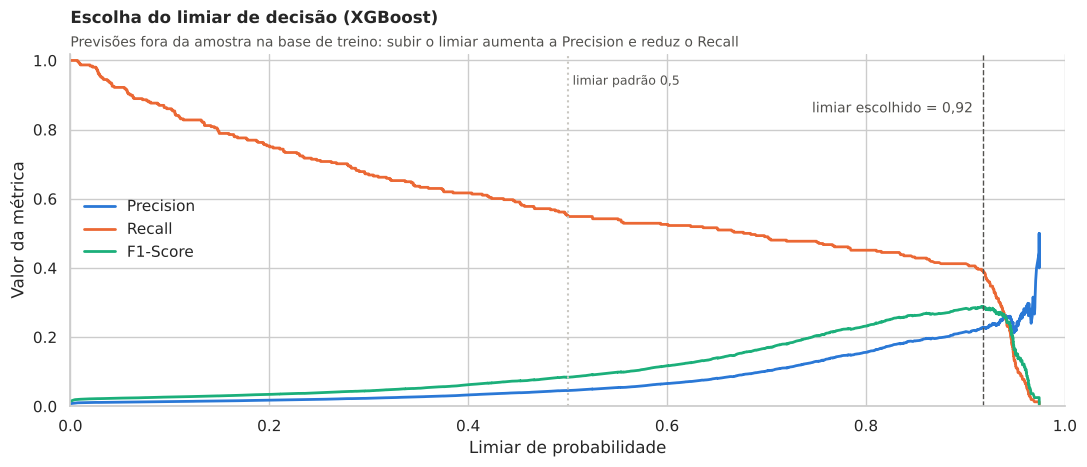

In [48]:
nome_final = tabela_cv['PR-AUC validação (CV)'].idxmax()
modelo_final = modelos[nome_final]
print(f'Modelo escolhido pela validação cruzada: {nome_final}')

# Probabilidades "fora da amostra" no treino (cada parte prevista por um modelo treinado nas outras)
prob_oof = cross_val_predict(modelo_final, X_train, y_train, groups=grupos_train, cv=cv_treino,
                             method='predict_proba')[:, 1]
prec_oof, rec_oof, limiares_oof = precision_recall_curve(y_train, prob_oof)
f1_oof = 2 * prec_oof[:-1] * rec_oof[:-1] / (prec_oof[:-1] + rec_oof[:-1] + 1e-12)
limiar_final = limiares_oof[np.argmax(f1_oof)]
print(f'Limiar que maximiza o F1 no treino (fora da amostra): {limiar_final:.3f}')

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(limiares_oof, prec_oof[:-1], color=CORES_MODELO['Árvore de Decisão'], linewidth=2, label='Precision')
ax.plot(limiares_oof, rec_oof[:-1], color=CORES_MOTIVO['Resignation'], linewidth=2, label='Recall')
ax.plot(limiares_oof, f1_oof, color=CORES_MODELO['Random Forest'], linewidth=2, label='F1-Score')
ax.axvline(0.5, color='#c9c7c1', linestyle=':', linewidth=1.5)
ax.text(0.505, 0.93, 'limiar padrão 0,5', fontsize=9, color='#52514e')
ax.axvline(limiar_final, color='#52514e', linestyle='--', linewidth=1)
ax.text(limiar_final - 0.01, 0.85, f'limiar escolhido = {limiar_final:.2f}'.replace('.', ','), fontsize=10, color='#52514e', ha='right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc='center left')
estilizar(ax, f'Escolha do limiar de decisão ({nome_final})',
          'Previsões fora da amostra na base de treino: subir o limiar aumenta a Precision e reduz o Recall',
          'Limiar de probabilidade', 'Valor da métrica')
plt.tight_layout()
plt.show()

,Acurácia,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
"XGBoost (limiar 0,5)",0.892,0.042,0.597,0.079,0.847,0.179
XGBoost (limiar ajustado),0.983,0.227,0.481,0.308,0.847,0.179


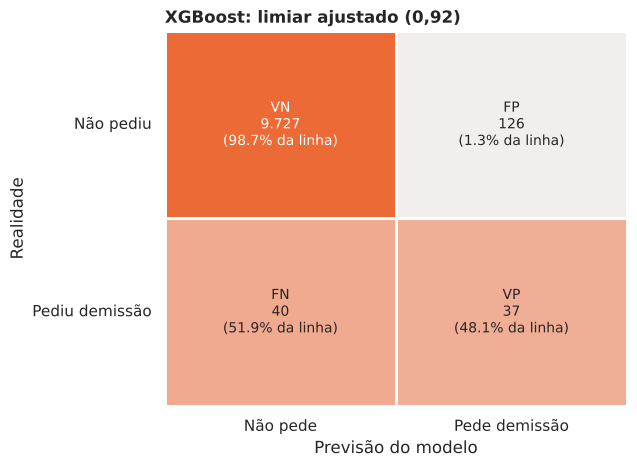

O modelo sinalizou 163 registros como risco; 37 realmente pediram demissão.
Ele encontrou 37 dos 77 pedidos de demissão do teste (48%).
Para comparação, sinalizar 163 pessoas ao acaso encontraria em média 1.3 pedidos de demissão.


In [49]:
prob_final = probabilidades[nome_final]
prev_final = (prob_final >= limiar_final).astype(int)

metricas_finais = pd.DataFrame({
    f'{nome_final} (limiar 0,5)': calcular_metricas(y_test, previsoes[nome_final], prob_final),
    f'{nome_final} (limiar ajustado)': calcular_metricas(y_test, prev_final, prob_final),
}).T
display(metricas_finais.round(3))

fig, ax = plt.subplots(figsize=(6.5, 4.8))
desenhar_matriz(ax, y_test, prev_final, f'{nome_final}: limiar ajustado ({limiar_final:.2f})'.replace('.', ','), CORES_MODELO[nome_final])
plt.tight_layout()
plt.show()

vp = ((prev_final == 1) & (y_test.values == 1)).sum()
fp = ((prev_final == 1) & (y_test.values == 0)).sum()
fn = ((prev_final == 0) & (y_test.values == 1)).sum()
print(f'O modelo sinalizou {vp + fp} registros como risco; {vp} realmente pediram demissão.')
print(f'Ele encontrou {vp} dos {vp + fn} pedidos de demissão do teste ({vp / (vp + fn):.0%}).')
print(f'Para comparação, sinalizar {vp + fp} pessoas ao acaso encontraria em média '
      f'{(vp + fp) * y_test.mean():.1f} pedidos de demissão.')

* O limiar ficou alto (0,92) porque o `scale_pos_weight` aumenta as probabilidades do XGBoost. Por isso elas funcionam como uma nota de risco, e não como a probabilidade real de saída.
* Com o limiar ajustado, a Precision subiu de 4% para **23%** e o F1 de 0,08 para **0,31**, com Recall de **48%**.
* Na prática: o modelo apontou 163 registros como risco e 37 realmente pediram demissão (cerca de 1 em cada 4). Escolhendo 163 pessoas ao acaso, encontraríamos pouco mais de 1.
* O limiar é uma decisão do RH: se der para conversar com mais pessoas, dá para baixar o limiar e encontrar mais casos, aceitando mais alarmes falsos.

### 7.5 Importância das features

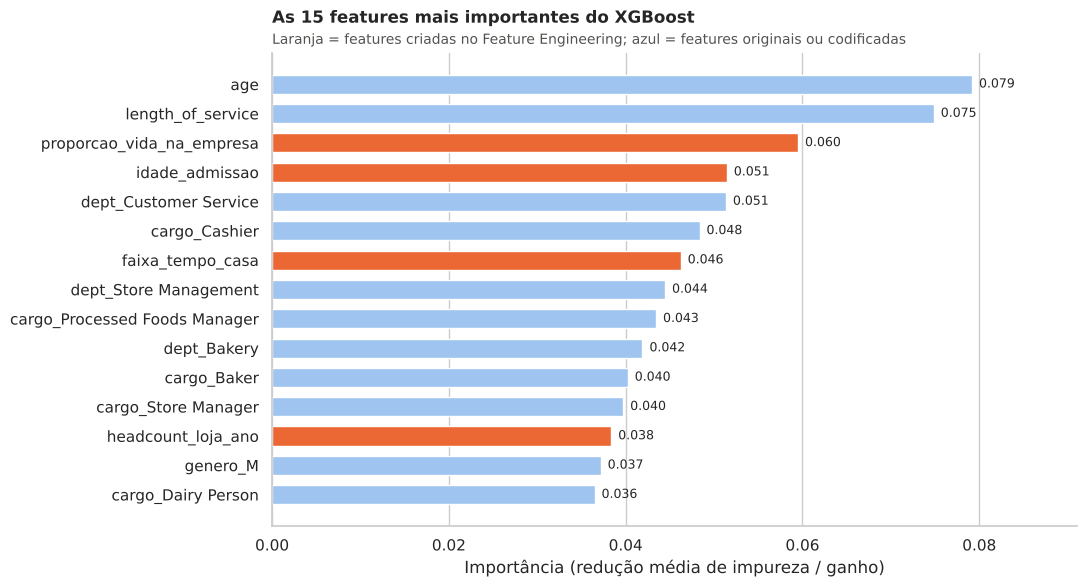

Posição das features criadas no ranking de importância:
  idade_admissao: 4º de 76 (importância 0.051)
  faixa_tempo_casa: 7º de 76 (importância 0.046)
  headcount_loja_ano: 13º de 76 (importância 0.038)
  proporcao_vida_na_empresa: 3º de 76 (importância 0.060)


In [50]:
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)
top = importancias.head(15).sort_values()
novas = ['idade_admissao', 'faixa_tempo_casa', 'headcount_loja_ano', 'proporcao_vida_na_empresa']

fig, ax = plt.subplots(figsize=(11, 6))
cores_imp = [CORES_MOTIVO['Resignation'] if c in novas else '#9fc4ef' for c in top.index]
ax.barh(top.index, top.values, color=cores_imp, height=0.65)
for i, v in enumerate(top.values):
    ax.text(v + top.max() * 0.01, i, f'{v:.3f}', va='center', fontsize=9)
ax.grid(axis='y', visible=False)
ax.set_xlim(0, top.max() * 1.15)
estilizar(ax, f'As 15 features mais importantes do {nome_final}',
          'Laranja = features criadas no Feature Engineering; azul = features originais ou codificadas',
          'Importância (redução média de impureza / ganho)', '')
plt.tight_layout()
plt.show()

print('Posição das features criadas no ranking de importância:')
ranking = importancias.rank(ascending=False).astype(int)
for f in novas:
    print(f'  {f}: {ranking[f]}º de {len(importancias)} (importância {importancias[f]:.3f})')

As features mais importantes confirmam a EDA: idade, tempo de empresa, trabalhar no Atendimento ao Cliente e ser Caixa. As features que criamos no Bloco 5 também ajudaram: `proporcao_vida_na_empresa` (sugerida pela IA) ficou em 3º lugar, `idade_admissao` em 4º e `faixa_tempo_casa` em 7º, entre 76 features. A `headcount_loja_ano` ficou em 13º.

Importante: a importância mostra **associação**, não causa. O modelo mostra que caixas jovens e com pouco tempo de casa têm mais risco, mas não explica por que eles saem.

### 7.6 Verificação final: treino × teste

In [51]:
comparacao_final = pd.DataFrame({
    nome: {
        'PR-AUC treino': average_precision_score(y_train, modelo.predict_proba(X_train)[:, 1]),
        'PR-AUC validação (CV)': tabela_cv.loc[nome, 'PR-AUC validação (CV)'],
        'PR-AUC teste': tabela_metricas.loc[nome, 'PR-AUC'],
        'ROC-AUC treino': roc_auc_score(y_train, modelo.predict_proba(X_train)[:, 1]),
        'ROC-AUC teste': tabela_metricas.loc[nome, 'ROC-AUC'],
    } for nome, modelo in modelos.items()
}).T
display(comparacao_final.round(3))

,PR-AUC treino,PR-AUC validação (CV),PR-AUC teste,ROC-AUC treino,ROC-AUC teste
Árvore de Decisão,0.157,0.120,0.160,0.941,0.780
Random Forest,0.211,0.135,0.186,0.963,0.851
XGBoost,0.206,0.141,0.179,0.972,0.847


* **PR-AUC:** o teste (0,16 a 0,19) ficou parecido com a validação (0,12 a 0,14) e com o treino (0,16 a 0,21). A validação cruzada estimou bem o desempenho em dados novos.
* **ROC-AUC:** aqui a diferença é maior (treino de 0,94 a 0,97 contra teste de 0,78 a 0,85), o que mostra um overfitting moderado, mais forte na Árvore de Decisão.
* Não há underfitting, e o overfitting foi controlado pelos limites que colocamos nos modelos. Daria para testar limites ainda mais fortes para diminuir essa diferença.

**Modelo escolhido: XGBoost com limiar ajustado.** Ele teve a maior PR-AUC na validação (0,141) e, no teste, ROC-AUC de 0,847, Precision de 23% e Recall de 48%. O Random Forest teve um desempenho praticamente igual e seria uma boa alternativa.

---
## 8. Conclusão Geral

Neste trabalho passamos por todas as etapas de um projeto de Data Science. Depois de limpar a base (corrigindo grafias, datas falsas e registros duplicados), a EDA mostrou que os desligamentos têm dois perfis bem diferentes: **jovens com pouco tempo de casa que pedem demissão** e **pessoas de 60 ou 65 anos que se aposentam**. Os pedidos de demissão se concentram nas lojas, principalmente entre caixas e no atendimento ao cliente, enquanto os layoffs aconteceram só em 2014 e 2015.

Com isso, decidimos prever apenas o pedido de demissão. Criamos novas features, treinamos três modelos e escolhemos o **XGBoost**, que consegue montar uma lista de colaboradores em risco muito melhor do que o acaso: com o limiar ajustado, ele encontrou quase metade dos pedidos de demissão do teste, e 1 em cada 4 pessoas apontadas realmente saiu.

**Resposta à pergunta do projeto:** os fatores mais ligados ao pedido de demissão são pouca idade, pouco tempo de casa, ter sido contratado jovem e trabalhar como caixa ou no atendimento das lojas. Dá para prever parcialmente: o modelo não sabe com certeza quem vai sair, mas ajuda o RH a saber com quem conversar primeiro.

**Sobre a pergunta da aula ("acertou 90%, é bom?"):** não necessariamente. Aqui, um modelo que nunca prevê demissão acerta 99,2% e é inútil. O que importa é quanto o modelo encontra da classe que nos interessa (Recall) sem gerar alarmes falsos demais (Precision).

**Recomendações para o RH:**
* Acompanhar de perto os dois primeiros anos de caixas e atendentes, que é a fase com mais pedidos de demissão.
* Usar a nota de risco do modelo como lista de prioridade para conversas de carreira e ações de retenção.
* Criar um plano de carreira para cargos de entrada nas lojas.
* Fazer planejamento sucessório no açougue e no hortifrúti, que perdem muita gente experiente por aposentadoria.

**Limitações:** a base não tem salário, desempenho nem pesquisa de clima, que costumam explicar muito da rotatividade. A Precision ainda é baixa, então o modelo deve apoiar conversas e nunca decisões automáticas sobre as pessoas, principalmente porque usa dados como idade e gênero. Além disso, os dados vão só até 2015.

**Próximos passos:** testar o modelo treinando com 2006-2013 e prevendo 2014-2015 (simulando o uso real), buscar novos dados (clima, salário, promoções) e testar limites mais fortes nos modelos para reduzir o overfitting.